# Calculate Headline Scores

In [3]:
import xarray as xr
import glob
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
import os
import numpy as np
from tqdm.auto import tqdm
from dask.distributed import Client, as_completed
from dask_jobqueue import PBSCluster
import duckdb
import matplotlib.pyplot as plt
import geopandas as gpd
from itertools import islice
import rasterio.features
import rasterio.transform
import cartopy.crs as ccrs

In [4]:
## Config
SCRATCH          = "/glade/derecho/scratch/dcalhoun/"
IFS_FC_DIR       = SCRATCH + "ecmwf/ifs/fc/0.125/2t/"
AIFS_FC_DIR      = SCRATCH + "ecmwf/aifs/fc/0.25/2t/"
AN_DIR           = SCRATCH + "ecmwf/ifs/an/0.125/2t/"
ERA_DIR          = SCRATCH + "ecmwf/era5/era5_2t/"
CLIM_PATH        = SCRATCH + "ecmwf/era5/era5_2t_climatology_1991_2020.nc"
IFS_COUNTY_PATH  = SCRATCH + "aggregated/ifs_fc_bias_anom_2t_county.parquet"
AIFS_COUNTY_PATH = SCRATCH + "aggregated/aifs_fc_bias_anom_2t_county.parquet"
SHAPEFILE        = SCRATCH + "census/shapefiles/nhgis0003_shapefile_tl2024_us_county_2024/US_county_2024.shp"
OUT_PATH_GRID    = SCRATCH + "headline_scores_gridded.csv"
OUT_PATH_ALL     = SCRATCH + "headline_scores.csv"
NUM_WORKERS      = 32

MODELS      = ["ifs", "aifs"]
INITS       = [0, 12]
LEADS       = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
YEARS       = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
MONTHS      = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
RESOLUTIONS = {"ifs": ["0.125", "0.25"], "aifs": ["0.25"]}
BOUNDS      = (49.5, 24.5, -125.0, -66.5)

In [5]:
## Utility functions

def read_fc_files(model, init, lead, year, month):
    init = fix_init(init)
    assert model in ("ifs", "aifs")
    d = {"ifs": IFS_FC_DIR, "aifs": AIFS_FC_DIR}
    files = glob.glob(d[model] + f"{init}/{lead}/{year}/{month:02}/*.nc")
    if not files:
        return None
    ds = xr.open_mfdataset(files)
    if model == "aifs":
        ds = fix_longitude(ds)
    return ds

def read_an_files(init, lead, year, month):
    init = fix_init(init)
    valid_step = relativedelta(hours=int(lead))
    start = datetime.strptime(f"{year}-{month}-01-{init}", "%Y-%m-%d-%H%M")
    end = start + relativedelta(months=1, days=-1)
    valid_dates = pd.date_range(start + valid_step, end + valid_step, freq="D")
    files = [
        AN_DIR + f"{d.year}/{d.month:02}/ifs_an_2t_{d.year}{d.month:02}{d.day:02}.nc"
        for d in valid_dates
        if os.path.exists(AN_DIR + f"{d.year}/{d.month:02}/ifs_an_2t_{d.year}{d.month:02}{d.day:02}.nc")
    ]
    return xr.open_mfdataset(files) if files else None

def read_era_files(year, month, bounds):
    N, S, W, E = bounds
    file = glob.glob(ERA_DIR + f"{year}{month:02}/*.nc")[0]
    ds = fix_longitude(xr.open_dataset(file))
    ds = ds.sel(
        latitude=slice(N, S),
        longitude=slice(W, E)
    )
    ds = fix_doy(ds)
    return make_ds(
        "t2m",
        ds.VAR_2T.values,
        {
            "doy": ds.doy.values,
            "latitude": ds.latitude.values,
            "longitude": ds.longitude.values,
        },
        {}
    )

def calculate_climatology(start, end, bounds):
    years = range(start, end + 1)
    months = range(1, 13)
    sample = read_era_files(years[0], months[0], bounds)
    n_lat = len(sample.latitude)
    n_lon = len(sample.longitude)
    clim_sum = np.zeros((365, n_lat, n_lon))
    clim_count = np.zeros(365)

    for year, month in tqdm([(y, m) for y in years for m in months], total=len(years) * len(months)):
        ds = read_era_files(year, month, bounds)
        for i, doy in enumerate(ds.doy.values):
            clim_sum[doy - 1] += ds.t2m.values[i]
            clim_count[doy - 1] += 1

    return make_ds("t2m", clim_sum / clim_count[:, None, None], {
        "doy": np.arange(1, 366),
        "latitude": sample.latitude.values,
        "longitude": sample.longitude.values,
    }, {})

def build_mask(geo_path, ds):
    gdf = gpd.read_file(geo_path).to_crs("EPSG:4326")
    lats = ds.latitude.values
    lons = ds.longitude.values

    transform = rasterio.transform.from_bounds(
        lons.min(), lats.min(), lons.max(), lats.max(),
        len(lons), len(lats)
    )

    mask = rasterio.features.geometry_mask(
        gdf.geometry,
        transform=transform,
        invert=True,
        out_shape=(len(lats), len(lons))
    )
    return make_ds("mask", mask, {"latitude": ds.latitude.values, "longitude": ds.longitude.values}, {"description": f"county mask based on {SHAPEFILE}"})

def coarsen(ds_fine, var="t2m"):
    lat_fine = ds_fine['latitude'].values
    lon_fine = ds_fine['longitude'].values
    lat_coarse = lat_fine[::2]
    lon_coarse = lon_fine[::2]
    data = ds_fine[var].values  # (time, lat, lon)
    nlat = len(lat_coarse)
    nlon = len(lon_coarse)
    nt = data.shape[0]
    data_coarse = np.zeros((nt, nlat, nlon), dtype=data.dtype)
    for i in range(nlat):
        for j in range(nlon):
            block = data[:, 2*i:2*i+2, 2*j:2*j+2]
            data_coarse[:, i, j] = block.mean(axis=(1, 2))
    return make_ds(var, data_coarse, {"time": ds_fine["time"].values, "latitude": lat_coarse, "longitude": lon_coarse}, {})

def fix_init(init):
    init_int = int(str(init).lstrip("0") or "0")
    assert init_int in (0, 12), f"Invalid init '{init}' (must be 00z or 12z)"
    return {0: "0000", 12: "1200"}[init_int]

def fix_doy(ds):
    mask = ~((ds.time.dt.month == 2) & (ds.time.dt.day == 29))
    ds = ds.sel(time=mask)
    times = pd.DatetimeIndex(ds.time.values)
    ds["doy"] = ("time", pd.to_datetime(times.strftime("2001-%m-%d")).dayofyear)
    return ds

def fix_longitude(ds):
    ds["longitude"] = (ds.longitude + 180) % 360 - 180
    return ds.sortby("longitude")

def make_ds(name, var, coords, attrs):
    return xr.Dataset(
        {name: (list(coords.keys()), var)},
        coords=coords,
        attrs=attrs
    )

def get_common_times(ds1, ds2):
    return np.intersect1d(ds1.time, ds2.time)

def resample(ds, ds_coords):
    return ds.sel(latitude=ds_coords.latitude, longitude=ds_coords.longitude, method='nearest')

def aw_avg(da):
    weights = np.cos(np.deg2rad(da.latitude))
    return da.mean(dim="time").weighted(weights).mean().values


def fc_data_exists(model, init, lead, year, month):
    init = fix_init(init)
    d = {"ifs": IFS_FC_DIR, "aifs": AIFS_FC_DIR}
    return bool(glob.glob(d[model] + f"{init}/{lead}/{year}/{month:02}/*.nc"))

def apply_mask(ds, mask):
    if ds is None:
        return None
    if isinstance(mask, np.ndarray):
        da = xr.DataArray(mask, dims=["latitude", "longitude"],
                          coords={"latitude": ds.latitude.values,
                                  "longitude": ds.longitude.values})
        return ds.where(da)
    return ds.where(mask.mask)

def batched(iterable, n):
    it = iter(iterable)
    while batch := list(islice(it, n)):
        yield batch

In [6]:
## Score computation

def compute_headline_scores(model, init, lead, year, month, res, mask=None):
    ds_fc = read_fc_files(model, init, lead, year, month)
    ds_an = read_an_files(init, lead, year, month)
    if ds_fc is None or ds_an is None:
        return None

    ds_fc = ds_fc.compute()
    ds_an = ds_an.compute()

    if model == "ifs" and str(res) == "0.25":
        ds_fc = coarsen(ds_fc)
        ds_an = coarsen(ds_an)
    if model == "aifs":
        ds_an = coarsen(ds_an)

    if mask is not None:
        ds_fc = apply_mask(ds_fc, mask)
        ds_an = apply_mask(ds_an, mask)

    times = get_common_times(ds_fc, ds_an)
    ds_fc_t = fix_doy(ds_fc.sel(time=times))
    ds_an_t = fix_doy(ds_an.sel(time=times))

    bias = (ds_fc_t.t2m - ds_an_t.t2m).values
    ds_bias = make_ds(
        "t2m_bias", bias,
        {"time": ds_fc_t.time.values,
         "latitude": ds_fc_t.latitude.values,
         "longitude": ds_fc_t.longitude.values},
        {"description": "2m temperature forecast bias", "units": "degC"}
    )

    ds_clim = resample(xr.open_dataset(CLIM_PATH).compute(), ds_fc_t)
    clim = xr.DataArray(
        ds_clim.t2m.values[ds_fc_t.doy.values - 1],
        dims=["time", "latitude", "longitude"],
        coords={"time": ds_fc_t.time.values,
                "latitude": ds_fc_t.latitude.values,
                "longitude": ds_fc_t.longitude.values},
    )
    if mask is not None:
        clim = apply_mask(clim, mask)
    fc_anom = ds_fc_t.t2m - clim
    an_anom = ds_an_t.t2m - clim

    weights = np.cos(np.deg2rad(ds_fc_t.latitude))
    acc = float(
        (fc_anom * an_anom).weighted(weights).sum(dim=["time", "latitude", "longitude"]) / (
            np.sqrt((fc_anom**2).weighted(weights).sum(dim=["time", "latitude", "longitude"])) *
            np.sqrt((an_anom**2).weighted(weights).sum(dim=["time", "latitude", "longitude"]))
        )
    )

    return {
        "source": "gridded",
        "model": model,
        "resolution": res,
        "init": fix_init(init),
        "valid_hour": (int(fix_init(init)[:2]) + lead) % 24,
        "lead": int(lead),
        "year": year,
        "month": month,
        "bias": float(aw_avg(ds_bias.t2m_bias)),
        "mae": float(aw_avg(abs(ds_bias.t2m_bias))),
        "mse": float(aw_avg(ds_bias.t2m_bias**2)),
        "acc": acc,
    }


def compute_scores_safe(model, init, lead, year, month, res, mask=None):
    try:
        result = compute_headline_scores(model, init, lead, year, month, res, mask)
        return result, None
    except Exception as e:
        return None, f"{model} {init} lead={lead} {year}/{month} res={res}: {e}"


def compute_county_scores():
    return duckdb.query(f"""
        SELECT 'county' as source, 'ifs' as model, '0.125' as resolution,
            STRFTIME(init_time, '%H%M') as init, HOUR(valid_time) as valid_hour,
            CAST(lead_time AS INT) as lead, YEAR(init_time) as year, MONTH(init_time) as month,
            SUM(bias * aland) / SUM(aland) as bias,
            SUM(abs_error * aland) / SUM(aland) as mae,
            SUM(aland * bias**2) / SUM(aland) as mse,
            SUM(aland * fc_anom * an_anom) / (
                SQRT(SUM(aland * fc_anom**2)) * SQRT(SUM(aland * an_anom**2))
            ) as acc
        FROM read_parquet('{IFS_COUNTY_PATH}')
        GROUP BY STRFTIME(init_time, '%H%M'), lead_time, YEAR(init_time), MONTH(init_time), HOUR(valid_time)
        UNION ALL
        SELECT 'county' as source, 'aifs' as model, '0.25' as resolution,
            STRFTIME(init_time, '%H%M') as init, HOUR(valid_time) as valid_hour,
            CAST(lead_time AS INT) as lead, YEAR(init_time) as year, MONTH(init_time) as month,
            SUM(bias * aland) / SUM(aland) as bias,
            SUM(abs_error * aland) / SUM(aland) as mae,
            SUM(aland * bias**2) / SUM(aland) as mse,
            SUM(aland * fc_anom * an_anom) / (
                SQRT(SUM(aland * fc_anom**2)) * SQRT(SUM(aland * an_anom**2))
            ) as acc
        FROM read_parquet('{AIFS_COUNTY_PATH}')
        GROUP BY STRFTIME(init_time, '%H%M'), lead_time, YEAR(init_time), MONTH(init_time), HOUR(valid_time)
        ORDER BY model, lead ASC
    """).df()

In [5]:
## Build combinations

combinations = [
    (model, init, lead, year, month, res)
    for model in MODELS
    for res in RESOLUTIONS[model]
    for init in INITS
    for lead in LEADS
    for year in YEARS
    for month in MONTHS
    if fc_data_exists(model, init, lead, year, month)
]
combinations.sort(key=lambda x: float(x[5]), reverse=True)
print(f"{len(combinations)} total combinations.")

6432 total combinations.


In [9]:
## Build masks

ds_fc = read_fc_files("ifs", 0, 12, 2025, 6)
mask = build_mask(SHAPEFILE, ds_fc)
mask_coarse = build_mask(SHAPEFILE, coarsen(ds_fc))

In [ ]:
## Calculate climatology

climatology = calculate_climatology(1991, 2020, BOUNDS)
climatology.to_netcdf(CLIM_PATH)

In [7]:
## Quick test

for k, v  in compute_headline_scores("ifs", 0, 12, 2025, 6, 0.125, mask).items():
    print(k, v)
print()
for k, v  in compute_headline_scores("ifs", 0, 12, 2025, 6, 0.25, mask_coarse).items():
    print(k, v)
print()
for k, v  in compute_headline_scores("aifs", 0, 12, 2025, 6, 0.25, mask_coarse).items():
    print(k, v)

source gridded
model ifs
resolution 0.125
init 0000
valid_hour 12
lead 12
year 2025
month 6
bias 0.10237905356774844
mae 0.730580418396432
mse 0.9044877460487283
acc 0.985398092449989

source gridded
model ifs
resolution 0.25
init 0000
valid_hour 12
lead 12
year 2025
month 6
bias 0.09999781697173907
mae 0.7139723314882332
mse 0.862223216959458
acc 0.9857098926392978

source gridded
model aifs
resolution 0.25
init 0000
valid_hour 12
lead 12
year 2025
month 6
bias 0.120583385542373
mae 0.8164710050067959
mse 1.2816956450457382
acc 0.9785281198248309


In [8]:
## Start dask cluster

cluster = PBSCluster(
    job_name="headline_scores_worker",
    cores=1,
    memory="8GB",
    processes=1,
    walltime="00:30:00",
    queue="main",
    resource_spec="select=1:ncpus=1:mem=8GB",
    log_directory=SCRATCH + "dask_logs/",
)
cluster.scale(NUM_WORKERS)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client.wait_for_workers(NUM_WORKERS, timeout=300)
print(f"Workers ready: {len(client.scheduler_info()['workers'])}")

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/dcalhoun/proxy/8787/status
Workers ready: 5


In [9]:
## Scatter masks to workers

mask_125 = client.scatter(mask.mask.values, broadcast=True)
mask_25 = client.scatter(mask_coarse.mask.values, broadcast=True)

In [10]:
## Submit workers in batches

BATCH_SIZE = 100

results = []
failures = []

with tqdm(total=len(combinations)) as pbar:
    for batch in batched(combinations, BATCH_SIZE):
        futures = []
        for model, init, lead, year, month, res in batch:
            mask_future = mask_125 if str(res) == "0.125" else mask_25
            futures.append(client.submit(
                compute_scores_safe,
                model, init, lead, year, month, res, mask_future
            ))
        for future in as_completed(futures):
            try:
                result, error = future.result()
                if error:
                    failures.append(error)
                    pbar.set_postfix_str(f"FAILED: {error[:60]}")
                elif result is not None:
                    results.append(result)
                    pbar.set_postfix_str(
                        f"last: {result['model']} {result['init']} "
                        f"lead={result['lead']} {result['year']}/{result['month']:02d}"
                    )
            except Exception as e:
                failures.append(str(e))
                pbar.set_postfix_str(f"FAILED: {str(e)[:60]}")
            pbar.update(1)

if results:
    pd.DataFrame(results).to_csv(OUT_PATH_GRID, mode="w", header=True, index=False)
    print(f"\n{len(results)} results written to {OUT_PATH_GRID}")

if failures:
    print(f"\n{len(failures)} failures:")
    for f in failures:
        print(f"  {f}")

client.close()
cluster.close()

  0%|          | 0/8040 [00:00<?, ?it/s]


8040 results written to /glade/derecho/scratch/dcalhoun/headline_scores.csv


In [10]:
## Finalize: append county scores

if not os.path.exists(OUT_PATH_GRID):
    print("No output file found.")
else:
    df_gridded = pd.read_csv(OUT_PATH_GRID, on_bad_lines="warn")
    df_gridded = df_gridded.dropna(subset=["model", "init", "lead", "year", "month"])

    df_county = compute_county_scores()
    df_county["lead"] = df_county["lead"].astype("int64")

    df_all = pd.concat([df_gridded, df_county], ignore_index=True)
    df_all.to_csv(OUT_PATH_ALL, index=False)
    print(f"Done. {len(df_gridded)} gridded + {len(df_county)} county records saved.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done. 8040 gridded + 4380 county records saved.


In [8]:
df_all = pd.read_csv(OUT_PATH_ALL)
df_all.head()

,source,model,resolution,init,valid_hour,lead,year,month,bias,mae,mse,acc
0,gridded,ifs,0.25,0,0,0,2017,4,-1.092767,1.247993,2.337122,0.980527
1,gridded,ifs,0.25,0,0,0,2019,2,-0.960439,1.175387,2.214002,0.974860
2,gridded,ifs,0.25,0,0,0,2018,2,-0.968059,1.184392,2.172850,0.983082
3,gridded,ifs,0.25,0,0,0,2016,6,-0.968484,1.177295,1.955083,0.984466
4,gridded,ifs,0.25,0,0,0,2018,11,-0.854951,1.046370,1.724320,0.968523


In [12]:
df_all.groupby(["source", "model", "resolution"])[["bias"]].describe()

bias                                          \
                           count      mean       std       min       25%   
source  model resolution                                                   
county  aifs  0.250        720.0  0.223611  0.300876 -1.166434  0.032551   
        ifs   0.125       3660.0 -0.203462  0.672239 -2.506358 -0.699398   
gridded aifs  0.250        720.0  0.166302  0.298585 -1.215535 -0.022100   
        ifs   0.125       3660.0 -0.203488  0.668660 -2.492128 -0.696852   
              0.250       3660.0 -0.201954  0.664264 -2.473599 -0.692966   

                                                        
                               50%       75%       max  
source  model resolution                                
county  aifs  0.250       0.211862  0.355240  1.892001  
        ifs   0.125      -0.196779  0.224586  1.899427  
gridded aifs  0.250       0.144982  0.302364  1.814019  
        ifs   0.125      -0.198187  0.220716  1.888751  
              0.250      -0.195675  0.219557  1.877458

In [13]:
df_all.groupby(["source", "model", "resolution"])[["mse"]].describe()

mse                                          \
                           count      mean       std       min       25%   
source  model resolution                                                   
county  aifs  0.250        720.0  3.601545  5.776388  0.030656  1.000427   
        ifs   0.125       3660.0  5.209901  6.663457  0.480674  1.724350   
gridded aifs  0.250        720.0  4.346623  5.845616  0.393480  1.675755   
        ifs   0.125       3660.0  5.794220  6.944209  0.642069  2.057258   
              0.250       3660.0  5.567884  6.828757  0.588918  1.925321   

                                                         
                               50%       75%        max  
source  model resolution                                 
county  aifs  0.250       1.663122  3.210467  38.556945  
        ifs   0.125       3.038348  5.372913  69.578478  
gridded aifs  0.250       2.458865  4.034980  39.498105  
        ifs   0.125       3.568916  6.101385  72.066547  
              0.250       3.352039  5.826375  70.882602

In [14]:
df_all.groupby(["source", "model", "resolution"])[["acc"]].describe()

acc                                          \
                           count      mean       std       min       25%   
source  model resolution                                                   
county  aifs  0.250        720.0  0.954253  0.070234  0.490511  0.958355   
        ifs   0.125       3660.0  0.931169  0.087111  0.272349  0.930328   
gridded aifs  0.250        720.0  0.944524  0.070279  0.489133  0.947184   
        ifs   0.125       3660.0  0.925304  0.087512  0.274113  0.922391   
              0.250       3660.0  0.927388  0.087313  0.268715  0.924912   

                                                        
                               50%       75%       max  
source  model resolution                                
county  aifs  0.250       0.977484  0.985975  0.999707  
        ifs   0.125       0.960238  0.976103  0.994907  
gridded aifs  0.250       0.966232  0.977392  0.996409  
        ifs   0.125       0.953797  0.971992  0.993827  
              0.250       0.955989  0.973548  0.994157

## Plot results

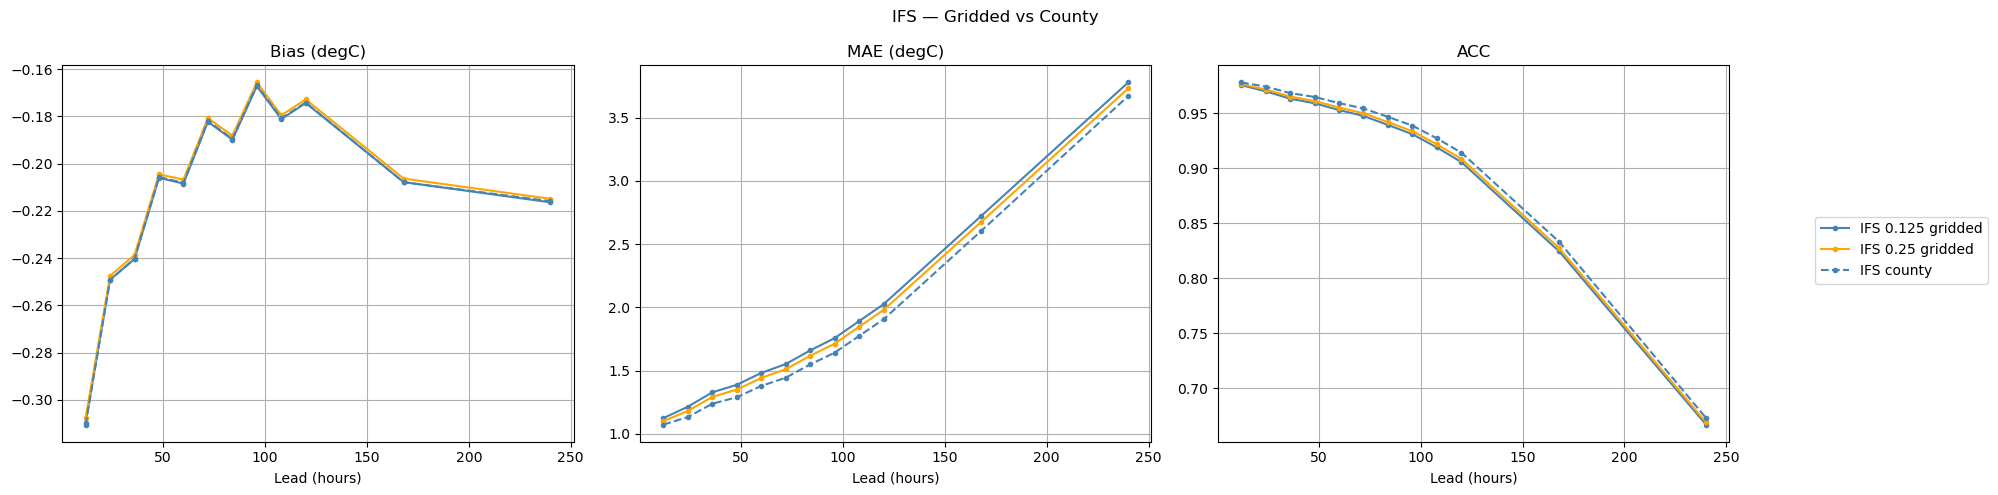

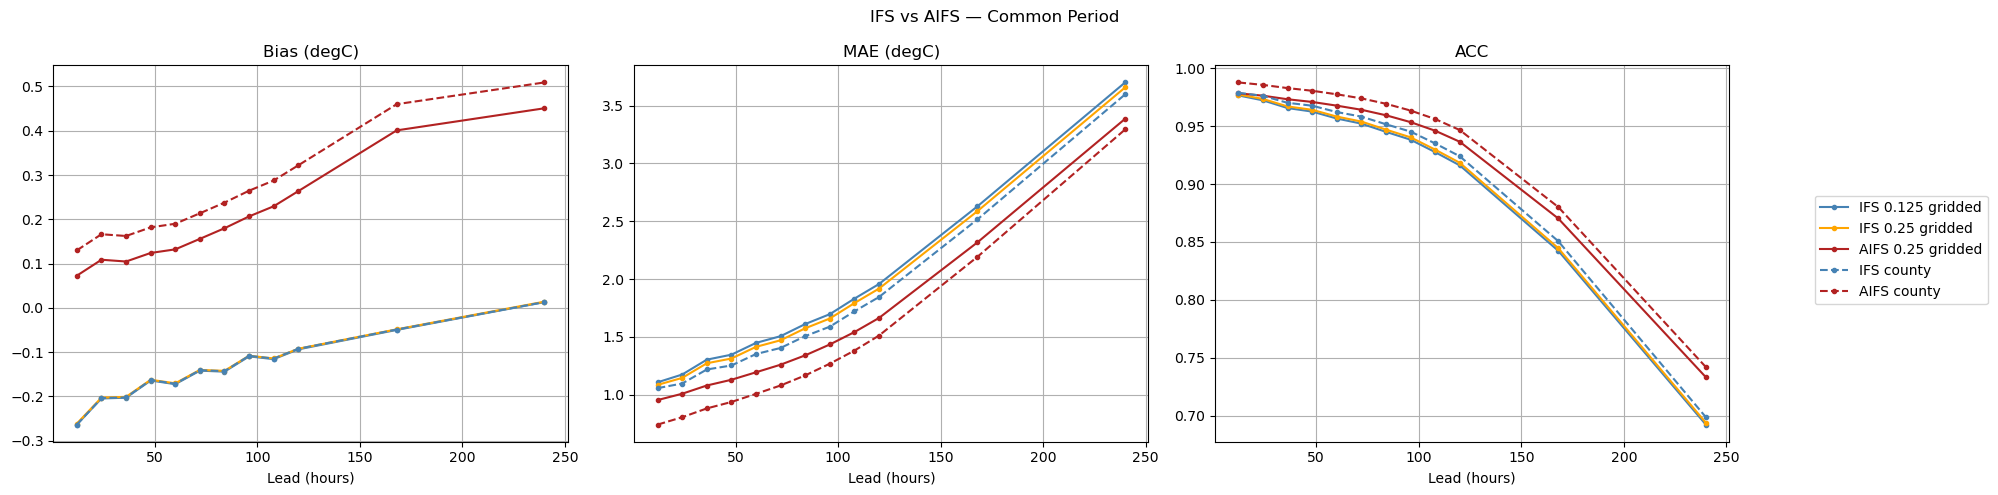

In [15]:
metrics = ["bias", "mae", "acc"]
titles = ["Bias (degC)", "MAE (degC)", "ACC"]
linestyles = {"gridded": "-", "county": "--"}
colors = {"ifs": "steelblue", "aifs": "firebrick"}
res_colors = {0.125: "steelblue", 0.25: "orange"}
common_keys = ["year", "month", "lead", "init"]

# --- Define base dataframes ---
df_all = df_all[df_all["lead"].isin(LEADS)]
ifs_grid_125 = df_all[(df_all["model"] == "ifs") & (df_all["resolution"] == 0.125) & (df_all["source"] == "gridded")]
ifs_grid_25 = df_all[(df_all["model"] == "ifs") & (df_all["resolution"] == 0.25) & (df_all["source"] == "gridded")]
aifs_grid_25 = df_all[(df_all["model"] == "aifs") & (df_all["resolution"] == 0.25) & (df_all["source"] == "gridded")]
ifs_county = df_all[(df_all["model"] == "ifs") & (df_all["resolution"] == 0.125) & (df_all["source"] == "county")]
aifs_county = df_all[(df_all["model"] == "aifs") & (df_all["resolution"] == 0.25) & (df_all["source"] == "county")]

# --- Common period ---
common_gridded = (
    ifs_grid_25[common_keys].drop_duplicates()
    .merge(aifs_grid_25[common_keys].drop_duplicates(), on=common_keys)
    .merge(ifs_grid_125[common_keys].drop_duplicates(), on=common_keys)
)
common_county = (
    ifs_county[common_keys].drop_duplicates()
    .merge(aifs_county[common_keys].drop_duplicates(), on=common_keys)
)
ifs_grid_125_c = ifs_grid_125.merge(common_gridded, on=common_keys)
ifs_grid_25_c = ifs_grid_25.merge(common_gridded, on=common_keys)
aifs_grid_25_c = aifs_grid_25.merge(common_gridded, on=common_keys)
ifs_county_c = ifs_county.merge(common_county, on=common_keys)
aifs_county_c = aifs_county.merge(common_county, on=common_keys)

# --- Plot 1: All IFS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "gridded", "orange"),
    (ifs_county,   "IFS county",         "county",  "steelblue"),
]:
    df_s = df_m.groupby("lead")[metrics].mean().reset_index()
    if df_s.empty:
        continue
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        line, = ax.plot(df_s["lead"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker=".")
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Lead (hours)")
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle("IFS — Gridded vs County")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("ifs_scores_by_lead.pdf")
plt.show()

# --- Plot 2: IFS vs AIFS common period ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125_c, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25_c,  "IFS 0.25 gridded",  "gridded", "orange"),
    (aifs_grid_25_c, "AIFS 0.25 gridded", "gridded", "firebrick"),
    (ifs_county_c,   "IFS county",         "county",  "steelblue"),
    (aifs_county_c,  "AIFS county",        "county",  "firebrick"),
]:
    df_s = df_m.groupby("lead")[metrics].mean().reset_index()
    if df_s.empty:
        continue
    for i, (ax, metric) in enumerate(zip(axes, metrics)):
        line, = ax.plot(df_s["lead"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker=".")
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Lead (hours)")
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle("IFS vs AIFS — Common Period")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("ifs_aifs_scores_by_lead.pdf")
plt.show()

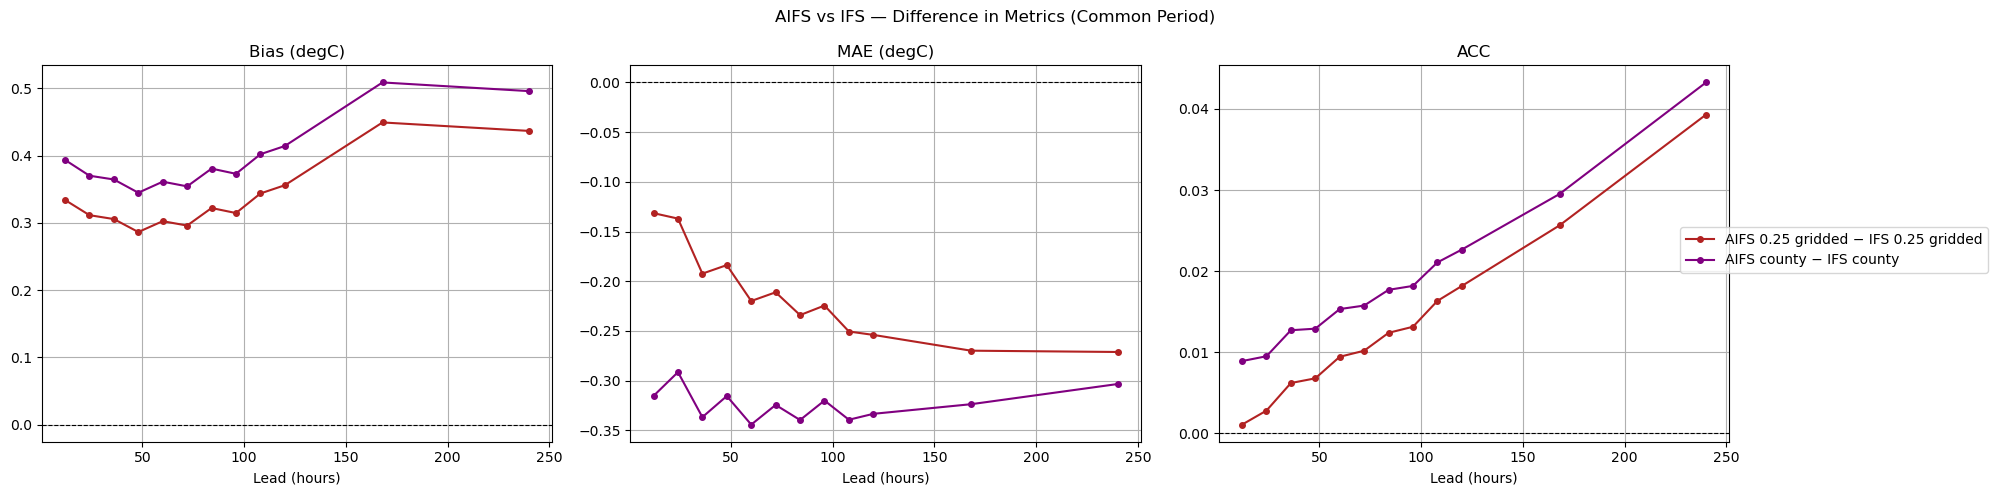

In [16]:
# AIFS 0.25 gridded vs IFS 0.25 gridded (common)
diff_grid = aifs_grid_25_c.groupby("lead")[metrics].mean().reset_index().set_index("lead") - \
            ifs_grid_25_c.groupby("lead")[metrics].mean().reset_index().set_index("lead")

# AIFS county vs IFS 0.25 gridded (common county period)
diff_county = aifs_county_c.groupby("lead")[metrics].mean().reset_index().set_index("lead") - \
              ifs_county_c.groupby("lead")[metrics].mean().reset_index().set_index("lead")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for diff, label, color in [
    (diff_grid,   "AIFS 0.25 gridded − IFS 0.25 gridded", "firebrick"),
    (diff_county, "AIFS county − IFS county",        "purple"),
]:
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        line, = ax.plot(diff.index, diff[metric], color=color, label=label, marker="o", ms=4)
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Lead (hours)")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle("AIFS vs IFS — Difference in Metrics (Common Period)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

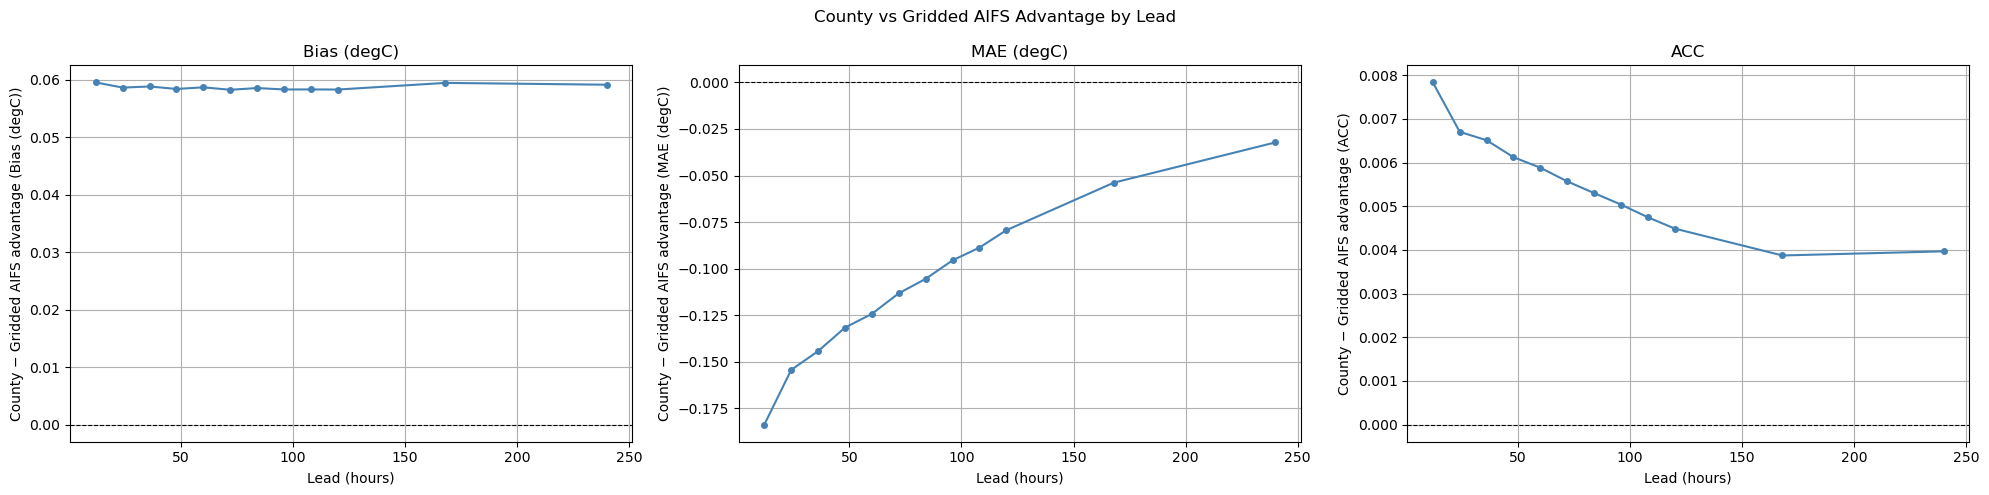

In [17]:
residuals_by_lead = (diff_county - diff_grid).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for ax, metric, title in zip(axes, metrics, titles):
    df_s = residuals_by_lead.groupby("lead")[metric].mean().reset_index()
    line, = ax.plot(df_s["lead"], df_s[metric], marker="o", ms=4, color="steelblue")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("Lead (hours)")
    ax.set_ylabel(f"County − Gridded AIFS advantage ({title})")
    ax.set_title(title)
    ax.grid(True)

plt.suptitle("County vs Gridded AIFS Advantage by Lead")
plt.tight_layout()
plt.show()

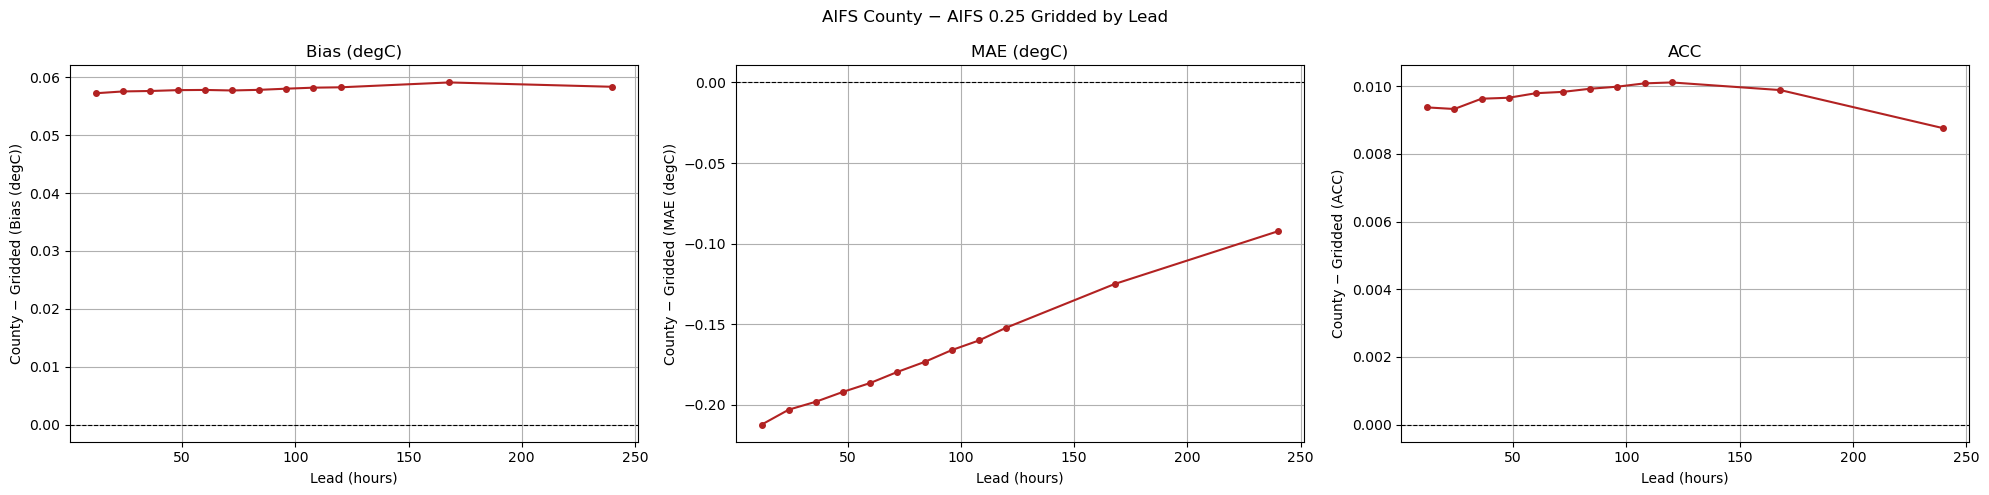

In [18]:
keys = ["year", "month", "lead"]

aifs_grid_mean = aifs_grid_25.groupby(keys)[metrics].mean()
aifs_county_mean = aifs_county.groupby(keys)[metrics].mean()

common = aifs_grid_mean.index.intersection(aifs_county_mean.index)
diff = (aifs_county_mean.loc[common] - aifs_grid_mean.loc[common]).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for ax, metric, title in zip(axes, metrics, titles):
    df_s = diff.groupby("lead")[metric].mean().reset_index()
    line, = ax.plot(df_s["lead"], df_s[metric], marker="o", ms=4, color="firebrick")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("Lead (hours)")
    ax.set_ylabel(f"County − Gridded ({title})")
    ax.set_title(title)
    ax.grid(True)

plt.suptitle("AIFS County − AIFS 0.25 Gridded by Lead")
plt.tight_layout()
plt.show()

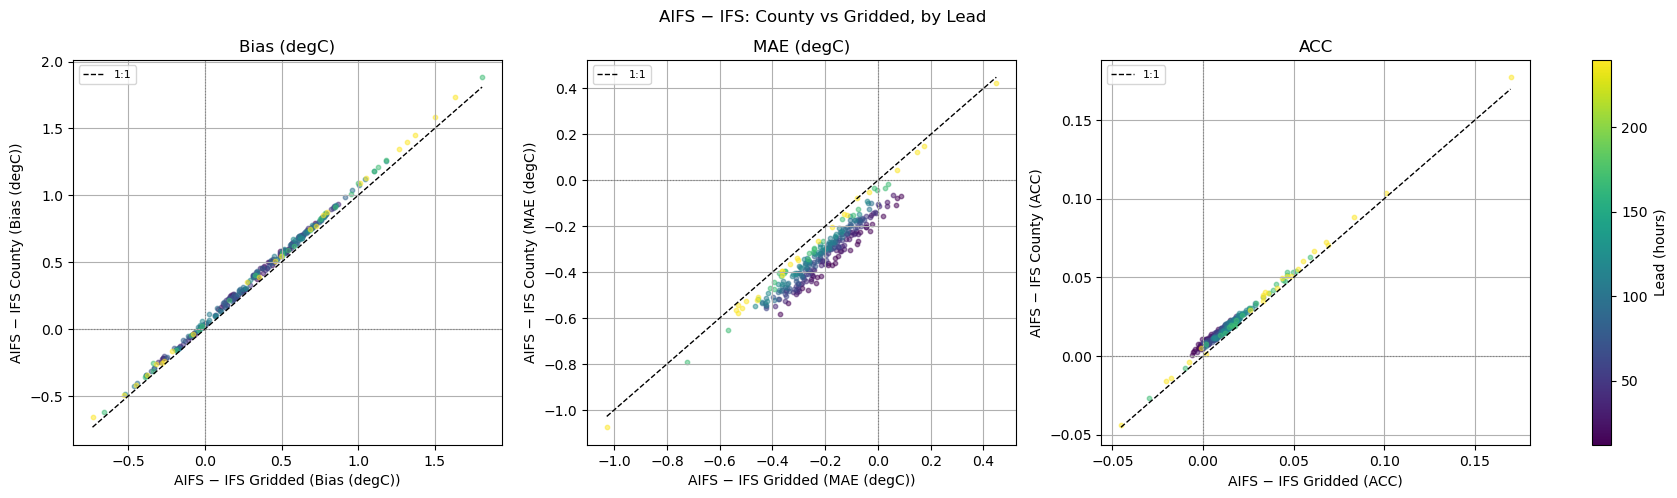

In [19]:
keys = ["year", "month", "lead"]

aifs_grid_mean = aifs_grid_25_c.groupby(keys)[metrics].mean()
ifs_grid_mean = ifs_grid_25_c.groupby(keys)[metrics].mean()
aifs_county_mean = aifs_county_c.groupby(keys)[metrics].mean()
ifs_county_mean = ifs_county_c.groupby(keys)[metrics].mean()

diff_grid = (aifs_grid_mean - ifs_grid_mean).dropna().reset_index()
diff_county = (aifs_county_mean - ifs_county_mean).dropna().reset_index()

common = diff_grid.merge(diff_county, on=keys, suffixes=("_grid", "_county"))

leads = sorted(common["lead"].unique())
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(leads), vmax=max(leads))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric, title in zip(axes, metrics, titles):
    for lead in leads:
        subset = common[common["lead"] == lead]
        ax.scatter(subset[f"{metric}_grid"], subset[f"{metric}_county"],
                   color=cmap(norm(lead)), alpha=0.5, s=10)
    ax.plot([common[f"{metric}_grid"].min(), common[f"{metric}_grid"].max()],
            [common[f"{metric}_grid"].min(), common[f"{metric}_grid"].max()],
            color="black", lw=1.0, ls="--", label="1:1")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_xlabel(f"AIFS − IFS Gridded ({title})")
    ax.set_ylabel(f"AIFS − IFS County ({title})")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.04, label="Lead (hours)")
plt.suptitle("AIFS − IFS: County vs Gridded, by Lead")
plt.show()

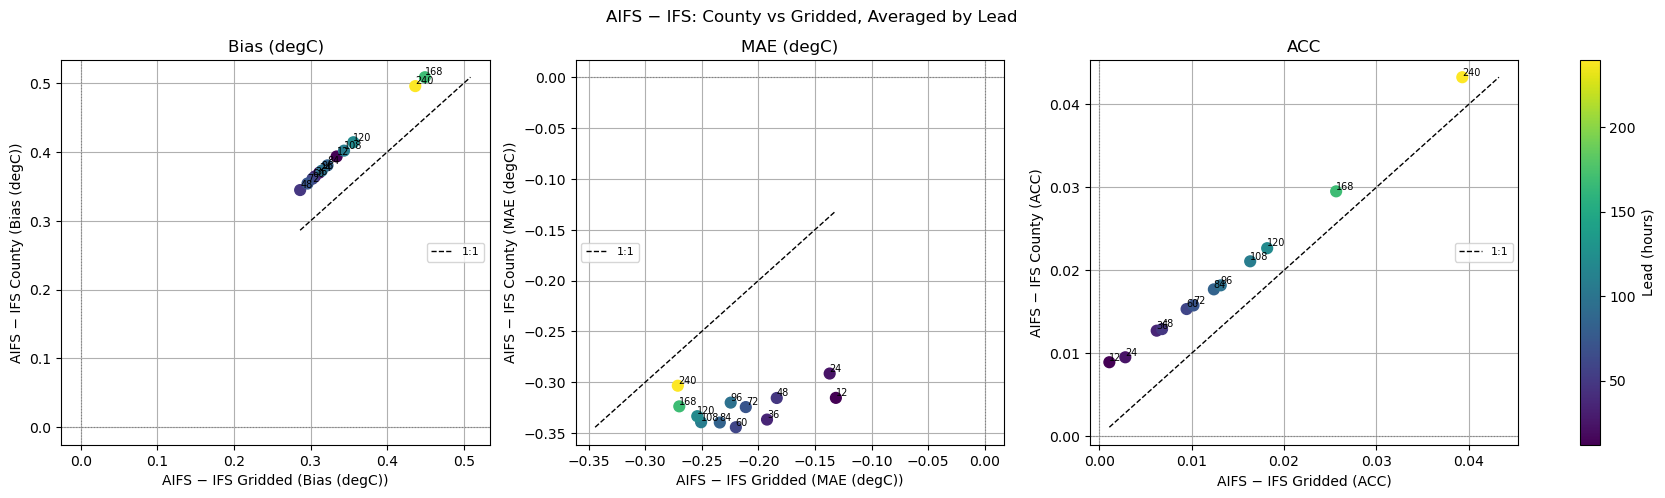

In [20]:
keys = ["year", "month", "lead"]

aifs_grid_mean = aifs_grid_25_c.groupby(keys)[metrics].mean()
ifs_grid_mean = ifs_grid_25_c.groupby(keys)[metrics].mean()
aifs_county_mean = aifs_county_c.groupby(keys)[metrics].mean()
ifs_county_mean = ifs_county_c.groupby(keys)[metrics].mean()

diff_grid = (aifs_grid_mean - ifs_grid_mean).dropna().reset_index()
diff_county = (aifs_county_mean - ifs_county_mean).dropna().reset_index()

common = diff_grid.merge(diff_county, on=keys, suffixes=("_grid", "_county"))
by_lead = common.groupby("lead")[[f"{m}_grid" for m in metrics] + [f"{m}_county" for m in metrics]].mean().reset_index()

leads = by_lead["lead"].values
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=leads.min(), vmax=leads.max())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric, title in zip(axes, metrics, titles):
    sc = ax.scatter(by_lead[f"{metric}_grid"], by_lead[f"{metric}_county"],
                    c=leads, cmap=cmap, norm=norm, s=60, zorder=3)
    for i, lead in enumerate(leads):
        ax.annotate(str(lead), (by_lead[f"{metric}_grid"].iloc[i], by_lead[f"{metric}_county"].iloc[i]),
                    fontsize=7, ha="left", va="bottom")
    lim = [min(by_lead[f"{metric}_grid"].min(), by_lead[f"{metric}_county"].min()),
           max(by_lead[f"{metric}_grid"].max(), by_lead[f"{metric}_county"].max())]
    ax.plot(lim, lim, color="black", lw=1.0, ls="--", label="1:1")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_xlabel(f"AIFS − IFS Gridded ({title})")
    ax.set_ylabel(f"AIFS − IFS County ({title})")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.04, label="Lead (hours)")
plt.suptitle("AIFS − IFS: County vs Gridded, Averaged by Lead")
plt.show()

In [18]:
from scipy import stats

results = []
for lead, group in common.groupby("lead"):
    x = group["mae_grid"].values
    y = group["mae_county"].values
    if len(x) < 3:
        continue
    res = stats.linregress(x, y)
    n = len(x)
    t_crit = stats.t.ppf(0.975, df=n-2)
    ci_slope = (res.slope - t_crit * res.stderr, res.slope + t_crit * res.stderr)
    ci_intercept = (res.intercept - t_crit * res.intercept_stderr, res.intercept + t_crit * res.intercept_stderr)
    results.append({
        "lead": lead,
        "slope": res.slope,
        "slope_lo": ci_slope[0],
        "slope_hi": ci_slope[1],
        "intercept": res.intercept,
        "intercept_lo": ci_intercept[0],
        "intercept_hi": ci_intercept[1],
        "r2": res.rvalue**2,
        "p": res.pvalue,
        "n": n,
    })

df_reg = pd.DataFrame(results)
print(df_reg.to_string(index=False))

 lead    slope  slope_lo  slope_hi  intercept  intercept_lo  intercept_hi       r2            p  n
    0 1.091035  1.031477  1.150593  -0.239236     -0.264719     -0.213752 0.984986 1.479782e-21 24
    6 1.043885  0.959495  1.128276  -0.160475     -0.168962     -0.151988 0.967651 6.930367e-18 24
   12 1.097694  1.051986  1.143402  -0.170998     -0.179289     -0.162706 0.991209 4.093519e-24 24
   18 1.083271  1.008219  1.158323  -0.166237     -0.174137     -0.158338 0.976035 2.546317e-19 24
   24 1.127660  1.079642  1.175679  -0.136955     -0.145342     -0.128569 0.990810 6.669560e-24 24
   36 1.103399  1.053954  1.152843  -0.124480     -0.135612     -0.113347 0.989833 2.027544e-23 24
   48 1.113970  1.060028  1.167913  -0.110787     -0.122161     -0.099412 0.988148 1.096278e-22 24
   60 1.095568  1.044230  1.146905  -0.103329     -0.115953     -0.090706 0.988893 5.365427e-23 24
   72 1.096083  1.039277  1.152889  -0.093018     -0.106279     -0.079756 0.986447 4.796185e-22 24
   84 1.07

In [19]:
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

for lead in df_reg["lead"]:
    group = common[common["lead"] == lead]
    x = group["mae_grid"].values
    y = group["mae_county"].values
    slope, intercept, *_ = stats.linregress(x, y)
    residuals = y - (slope * x + intercept)
    dw = durbin_watson(residuals)
    print(f"lead={lead:4d}  DW={dw:.3f}")

lead=   0  DW=0.622
lead=   6  DW=0.421
lead=  12  DW=0.573
lead=  18  DW=0.432
lead=  24  DW=0.694
lead=  36  DW=0.520
lead=  48  DW=0.627
lead=  60  DW=0.532
lead=  72  DW=0.626
lead=  84  DW=0.759
lead=  96  DW=0.793
lead= 108  DW=0.832
lead= 120  DW=0.793
lead= 168  DW=0.818
lead= 240  DW=0.929


In [20]:
import statsmodels.api as sm

results = []
for lead, group in common.groupby("lead"):
    x = group["mae_grid"].values
    y = group["mae_county"].values
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    hac = model.get_robustcov_results(cov_type="HAC", maxlags=3)
    
    results.append({
        "lead": lead,
        "slope": hac.params[1],
        "slope_lo": hac.conf_int()[1][0],
        "slope_hi": hac.conf_int()[1][1],
        "intercept": hac.params[0],
        "intercept_lo": hac.conf_int()[0][0],
        "intercept_hi": hac.conf_int()[0][1],
        "r2": model.rsquared,
        "p": hac.pvalues[1],
        "n": len(x),
    })

df_reg_hac = pd.DataFrame(results)
print(df_reg_hac.to_string(index=False))

 lead    slope  slope_lo  slope_hi  intercept  intercept_lo  intercept_hi       r2            p  n
    0 1.091035  1.047301  1.134769  -0.239236     -0.258148     -0.220323 0.984986 1.783931e-24 24
    6 1.043885  0.955223  1.132548  -0.160475     -0.173268     -0.147682 0.967651 1.982835e-17 24
   12 1.097694  1.057608  1.137780  -0.170998     -0.180500     -0.161495 0.991209 2.330135e-25 24
   18 1.083271  1.006954  1.159589  -0.166237     -0.178497     -0.153978 0.976035 3.647418e-19 24
   24 1.127660  1.084601  1.170720  -0.136955     -0.145623     -0.128287 0.990810 6.177666e-25 24
   36 1.103399  1.049387  1.157410  -0.124480     -0.134393     -0.114567 0.989833 1.386884e-22 24
   48 1.113970  1.050962  1.176978  -0.110787     -0.121772     -0.099801 0.988148 3.194757e-21 24
   60 1.095568  1.035086  1.156049  -0.103329     -0.115017     -0.091642 0.988893 1.888042e-21 24
   72 1.096083  1.025381  1.166786  -0.093018     -0.106615     -0.079421 0.986447 5.468400e-20 24
   84 1.07

In [21]:
from sklearn.utils import resample

def block_bootstrap_ci(x, y, n_boot=1000, block_size=3, ci=95):
    n = len(x)
    slopes, intercepts = [], []
    n_blocks = int(np.ceil(n / block_size))
    for _ in range(n_boot):
        # Sample blocks with replacement
        block_starts = np.random.choice(n - block_size + 1, size=n_blocks, replace=True)
        idx = np.concatenate([np.arange(s, s + block_size) for s in block_starts])[:n]
        x_b, y_b = x[idx], y[idx]
        slope, intercept, *_ = stats.linregress(x_b, y_b)
        slopes.append(slope)
        intercepts.append(intercept)
    lo = (100 - ci) / 2
    hi = 100 - lo
    return (
        np.percentile(slopes, lo), np.percentile(slopes, hi),
        np.percentile(intercepts, lo), np.percentile(intercepts, hi),
    )

results = []
for lead, group in common.groupby("lead"):
    x = group["mae_grid"].values
    y = group["mae_county"].values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    sl_lo, sl_hi, int_lo, int_hi = block_bootstrap_ci(x, y)
    results.append({
        "lead": lead,
        "slope": slope, "slope_lo": sl_lo, "slope_hi": sl_hi,
        "intercept": intercept, "intercept_lo": int_lo, "intercept_hi": int_hi,
        "r2": r**2, "p": p, "n": len(x),
    })

df_reg_boot = pd.DataFrame(results)
print(df_reg_boot.to_string(index=False))

 lead    slope  slope_lo  slope_hi  intercept  intercept_lo  intercept_hi       r2            p  n
    0 1.091035  1.025551  1.159538  -0.239236     -0.265357     -0.214675 0.984986 1.479782e-21 24
    6 1.043885  0.927871  1.113398  -0.160475     -0.171000     -0.146475 0.967651 6.930367e-18 24
   12 1.097694  1.052012  1.143853  -0.170998     -0.180622     -0.162468 0.991209 4.093519e-24 24
   18 1.083271  0.982311  1.168921  -0.166237     -0.178417     -0.151823 0.976035 2.546317e-19 24
   24 1.127660  1.081488  1.185258  -0.136955     -0.145695     -0.127900 0.990810 6.669560e-24 24
   36 1.103399  1.050777  1.160594  -0.124480     -0.133678     -0.111729 0.989833 2.027544e-23 24
   48 1.113970  1.055014  1.181371  -0.110787     -0.121313     -0.098454 0.988148 1.096278e-22 24
   60 1.095568  1.049736  1.163389  -0.103329     -0.111942     -0.089242 0.988893 5.365427e-23 24
   72 1.096083  1.033092  1.170190  -0.093018     -0.104957     -0.077714 0.986447 4.796185e-22 24
   84 1.07

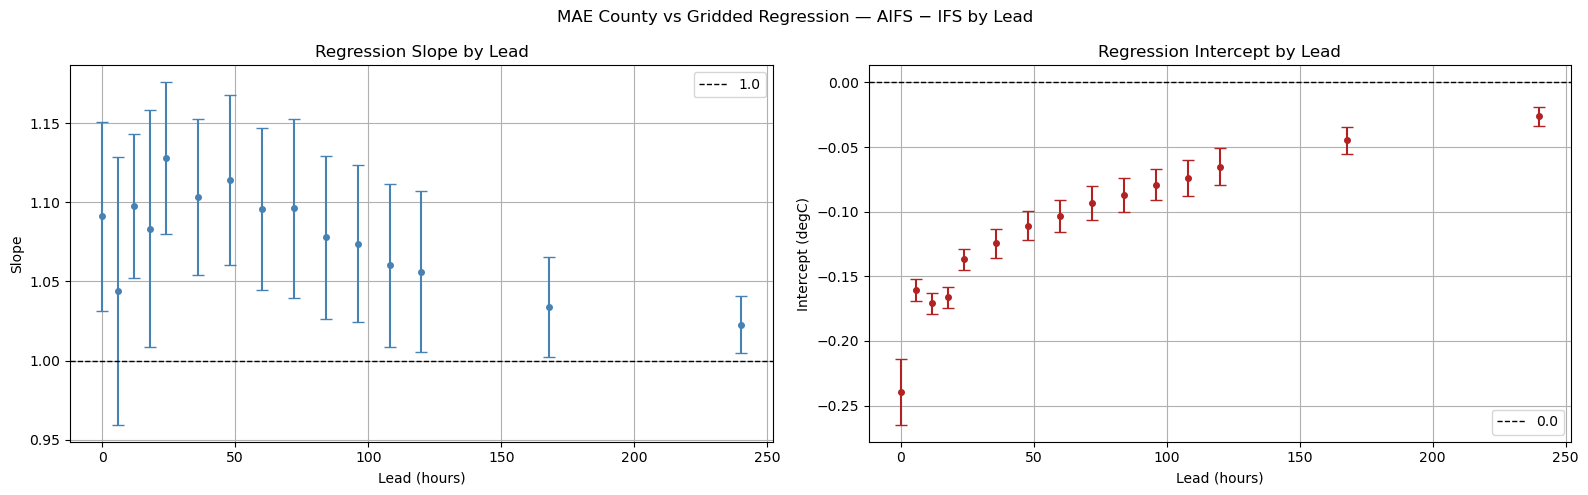

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Slope ---
axes[0].errorbar(df_reg["lead"], df_reg["slope"],
                 yerr=[df_reg["slope"] - df_reg["slope_lo"], df_reg["slope_hi"] - df_reg["slope"]],
                 fmt="o", ms=4, color="steelblue", ecolor="steelblue", capsize=4, elinewidth=1.5)
axes[0].axhline(1.0, color="black", lw=1.0, ls="--", label="1.0")
axes[0].set_xlabel("Lead (hours)")
axes[0].set_ylabel("Slope")
axes[0].set_title("Regression Slope by Lead")
axes[0].legend()
axes[0].grid(True)

# --- Intercept ---
axes[1].errorbar(df_reg["lead"], df_reg["intercept"],
                 yerr=[df_reg["intercept"] - df_reg["intercept_lo"], df_reg["intercept_hi"] - df_reg["intercept"]],
                 fmt="o", ms=4, color="firebrick", ecolor="firebrick", capsize=4, elinewidth=1.5)
axes[1].axhline(0.0, color="black", lw=1.0, ls="--", label="0.0")
axes[1].set_xlabel("Lead (hours)")
axes[1].set_ylabel("Intercept (degC)")
axes[1].set_title("Regression Intercept by Lead")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("MAE County vs Gridded Regression — AIFS − IFS by Lead")
plt.tight_layout()
plt.show()

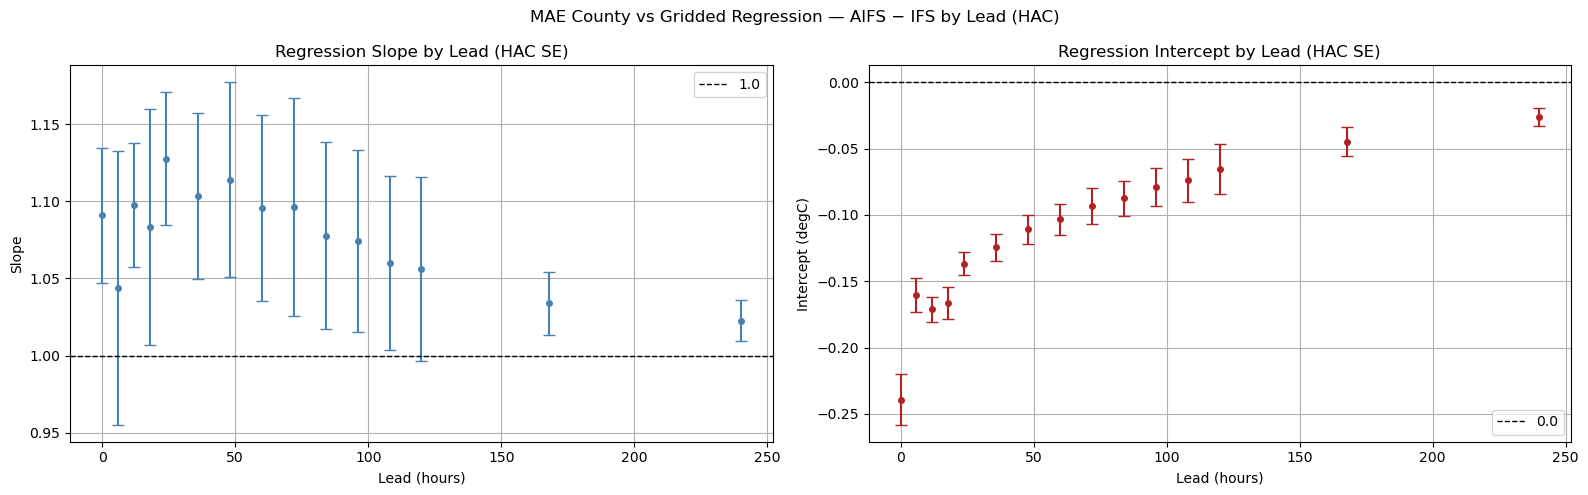

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Slope ---
axes[0].errorbar(df_reg_hac["lead"], df_reg_hac["slope"],
                 yerr=[df_reg_hac["slope"] - df_reg_hac["slope_lo"], df_reg_hac["slope_hi"] - df_reg_hac["slope"]],
                 fmt="o", ms=4, color="steelblue", ecolor="steelblue", capsize=4, elinewidth=1.5)
axes[0].axhline(1.0, color="black", lw=1.0, ls="--", label="1.0")
axes[0].set_xlabel("Lead (hours)")
axes[0].set_ylabel("Slope")
axes[0].set_title("Regression Slope by Lead (HAC SE)")
axes[0].legend()
axes[0].grid(True)

# --- Intercept ---
axes[1].errorbar(df_reg_hac["lead"], df_reg_hac["intercept"],
                 yerr=[df_reg_hac["intercept"] - df_reg_hac["intercept_lo"], df_reg_hac["intercept_hi"] - df_reg_hac["intercept"]],
                 fmt="o", ms=4, color="firebrick", ecolor="firebrick", capsize=4, elinewidth=1.5)
axes[1].axhline(0.0, color="black", lw=1.0, ls="--", label="0.0")
axes[1].set_xlabel("Lead (hours)")
axes[1].set_ylabel("Intercept (degC)")
axes[1].set_title("Regression Intercept by Lead (HAC SE)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("MAE County vs Gridded Regression — AIFS − IFS by Lead (HAC)")
plt.tight_layout()
plt.show()

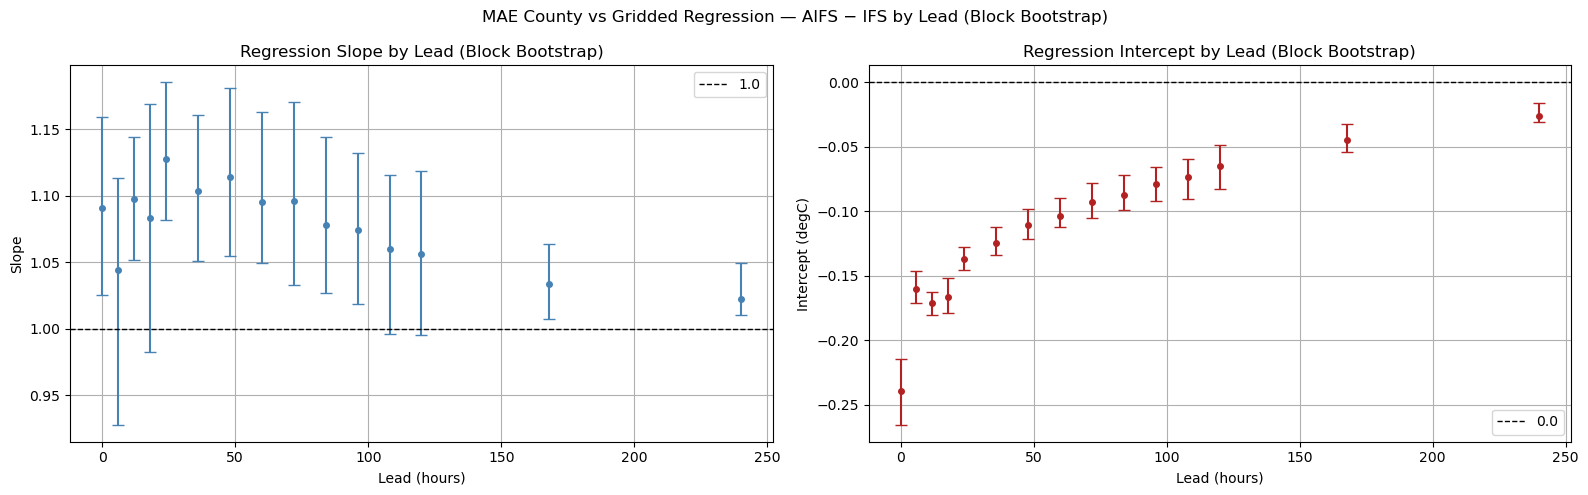

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].errorbar(df_reg_boot["lead"], df_reg_boot["slope"],
                 yerr=[df_reg_boot["slope"] - df_reg_boot["slope_lo"], df_reg_boot["slope_hi"] - df_reg_boot["slope"]],
                 fmt="o", ms=4, color="steelblue", ecolor="steelblue", capsize=4, elinewidth=1.5)
axes[0].axhline(1.0, color="black", lw=1.0, ls="--", label="1.0")
axes[0].set_xlabel("Lead (hours)")
axes[0].set_ylabel("Slope")
axes[0].set_title("Regression Slope by Lead (Block Bootstrap)")
axes[0].legend()
axes[0].grid(True)

axes[1].errorbar(df_reg_boot["lead"], df_reg_boot["intercept"],
                 yerr=[df_reg_boot["intercept"] - df_reg_boot["intercept_lo"], df_reg_boot["intercept_hi"] - df_reg_boot["intercept"]],
                 fmt="o", ms=4, color="firebrick", ecolor="firebrick", capsize=4, elinewidth=1.5)
axes[1].axhline(0.0, color="black", lw=1.0, ls="--", label="0.0")
axes[1].set_xlabel("Lead (hours)")
axes[1].set_ylabel("Intercept (degC)")
axes[1].set_title("Regression Intercept by Lead (Block Bootstrap)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("MAE County vs Gridded Regression — AIFS − IFS by Lead (Block Bootstrap)")
plt.tight_layout()
plt.show()

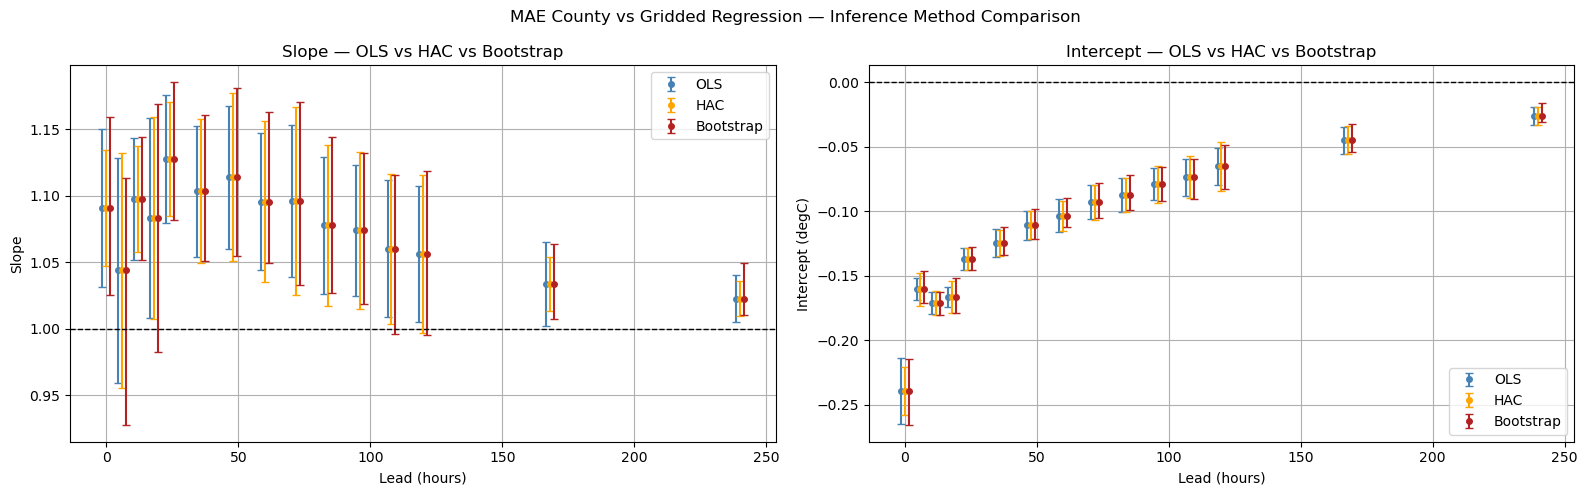

In [25]:
method_dfs = [
    (df_reg,      "OLS",       "steelblue"),
    (df_reg_hac,  "HAC",       "orange"),
    (df_reg_boot, "Bootstrap", "firebrick"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
offsets = [-1.5, 0, 1.5]

for (df_m, label, color), offset in zip(method_dfs, offsets):
    axes[0].errorbar(df_m["lead"] + offset, df_m["slope"],
                     yerr=[df_m["slope"] - df_m["slope_lo"], df_m["slope_hi"] - df_m["slope"]],
                     fmt="o", ms=4, color=color, ecolor=color, capsize=3, elinewidth=1.5, label=label)
    axes[1].errorbar(df_m["lead"] + offset, df_m["intercept"],
                     yerr=[df_m["intercept"] - df_m["intercept_lo"], df_m["intercept_hi"] - df_m["intercept"]],
                     fmt="o", ms=4, color=color, ecolor=color, capsize=3, elinewidth=1.5, label=label)

axes[0].axhline(1.0, color="black", lw=1.0, ls="--")
axes[0].set_xlabel("Lead (hours)")
axes[0].set_ylabel("Slope")
axes[0].set_title("Slope — OLS vs HAC vs Bootstrap")
axes[0].legend()
axes[0].grid(True)

axes[1].axhline(0.0, color="black", lw=1.0, ls="--")
axes[1].set_xlabel("Lead (hours)")
axes[1].set_ylabel("Intercept (degC)")
axes[1].set_title("Intercept — OLS vs HAC vs Bootstrap")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("MAE County vs Gridded Regression — Inference Method Comparison")
plt.tight_layout()
plt.show()

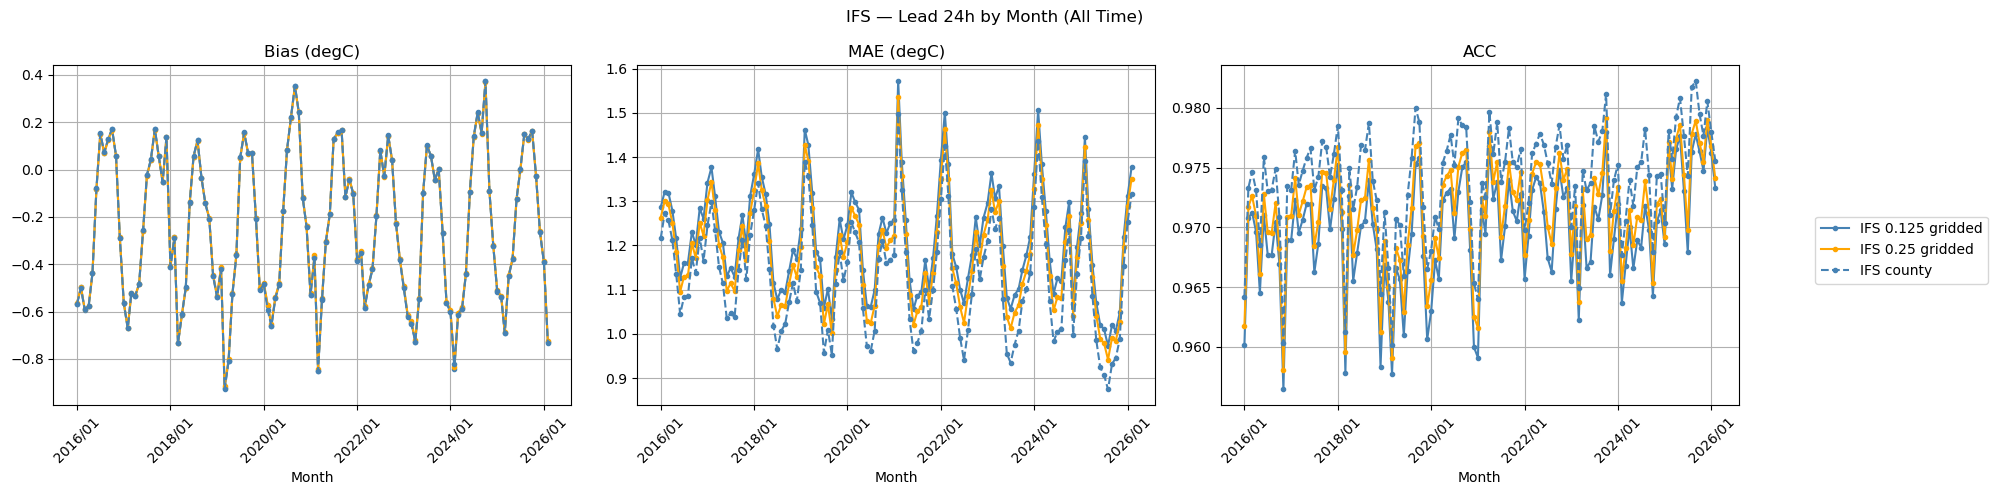

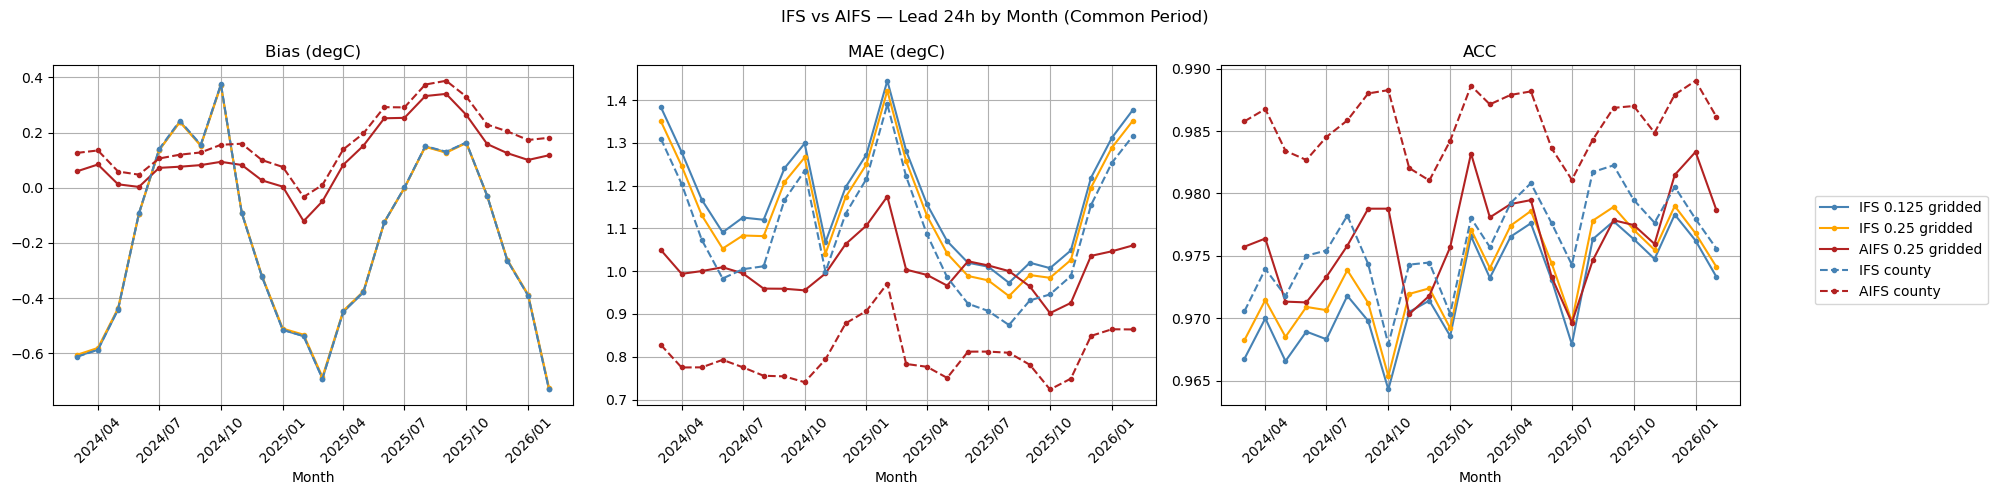

In [21]:
LEAD = 24

# --- Plot 1: IFS all time, lead=240, by yearmonth ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "gridded", "orange"),
    (ifs_county,   "IFS county",         "county",  "steelblue"),
]:
    df_s = df_m[df_m["lead"] == LEAD].groupby(["year", "month"])[metrics].mean().reset_index()
    df_s["ym"] = pd.to_datetime(df_s[["year", "month"]].assign(day=1))
    df_s = df_s.sort_values("ym")
    if df_s.empty:
        continue
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        line, = ax.plot(df_s["ym"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker="o", ms=3)
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.grid(True)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y/%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle(f"IFS — Lead {LEAD}h by Month (All Time)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("ifs_scores_ts.pdf")
plt.show()

# --- Plot 2: Common period, lead=240, by yearmonth ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125_c, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25_c,  "IFS 0.25 gridded",  "gridded", "orange"),
    (aifs_grid_25_c, "AIFS 0.25 gridded", "gridded", "firebrick"),
    (ifs_county_c,   "IFS county",         "county",  "steelblue"),
    (aifs_county_c,  "AIFS county",        "county",  "firebrick"),
]:
    df_s = df_m[df_m["lead"] == LEAD].groupby(["year", "month"])[metrics].mean().reset_index()
    df_s["ym"] = pd.to_datetime(df_s[["year", "month"]].assign(day=1))
    df_s = df_s.sort_values("ym")
    if df_s.empty:
        continue
    for i, (ax, metric) in enumerate(zip(axes, metrics)):
        line, = ax.plot(df_s["ym"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker="o", ms=3)
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.grid(True)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y/%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle(f"IFS vs AIFS — Lead {LEAD}h by Month (Common Period)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("ifs_aifs_scores_ts.pdf")
plt.show()

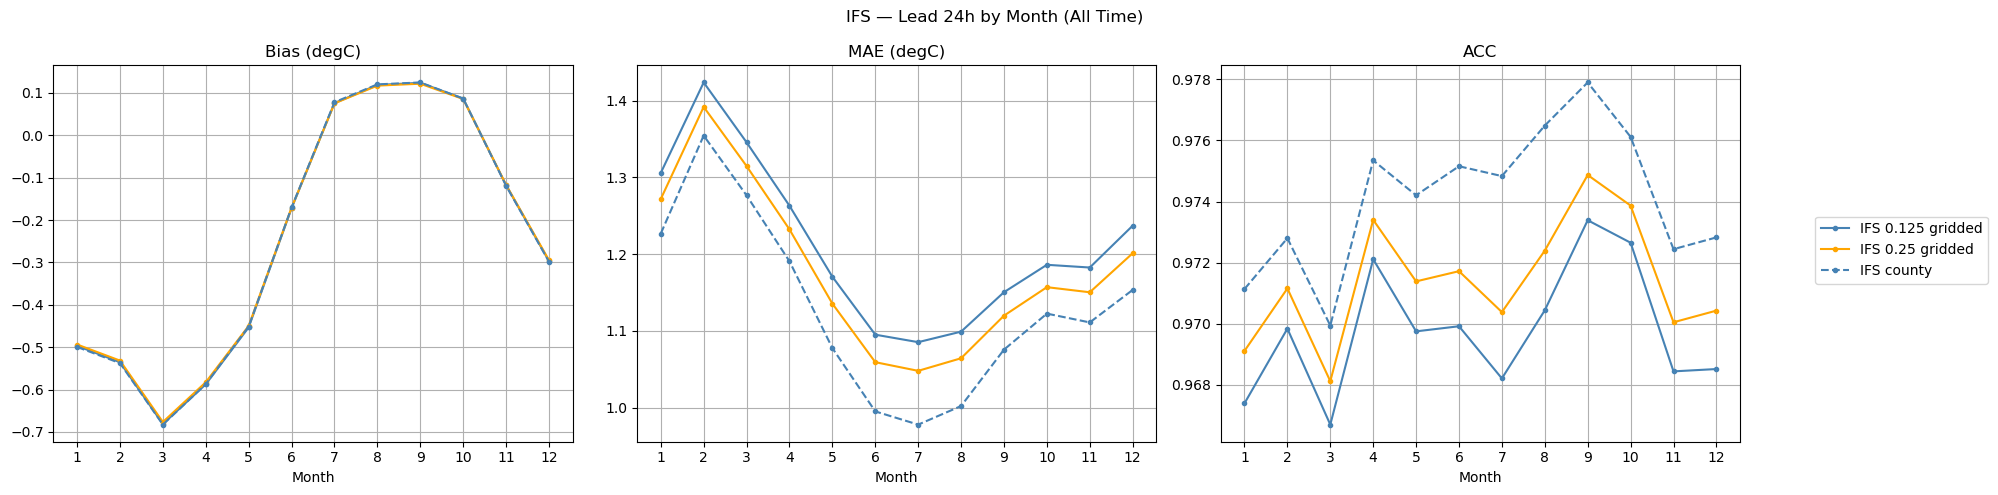

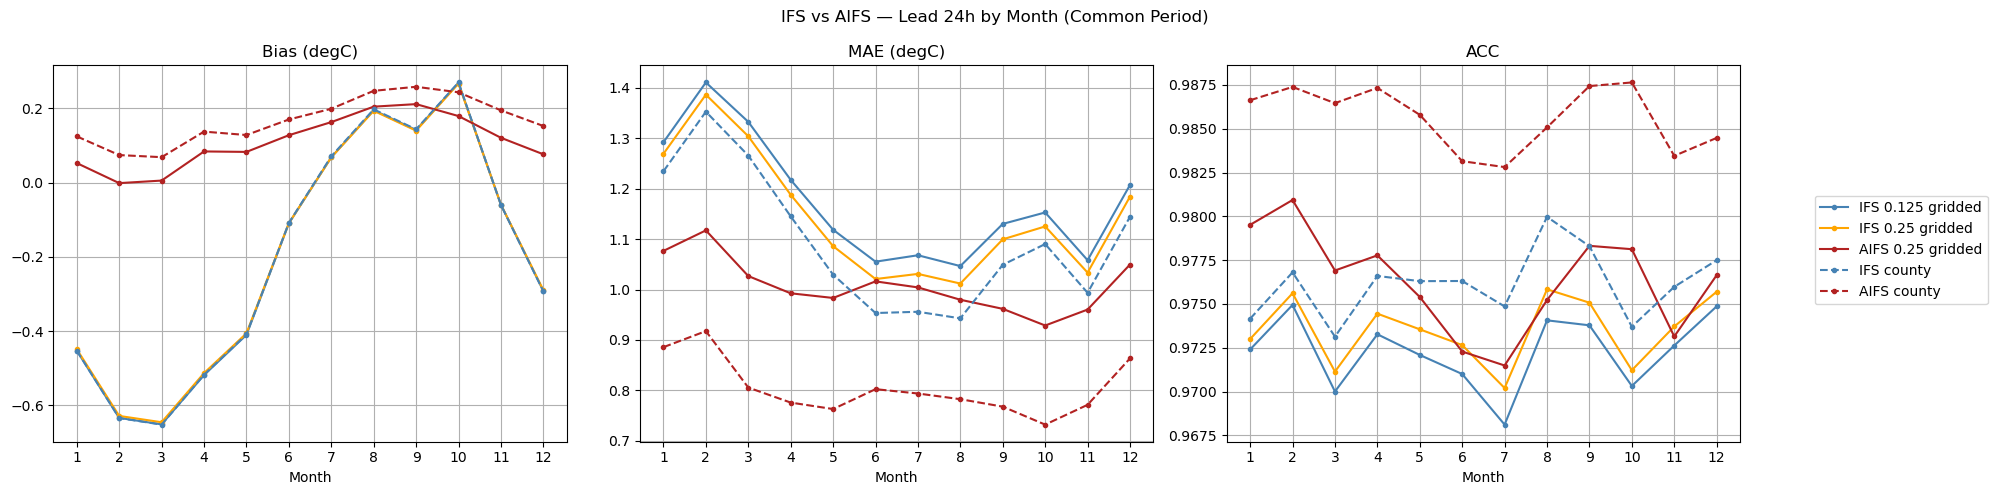

In [22]:
LEAD = 24

# --- Plot 1: IFS all time, one lead, by month averaged across years ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "gridded", "orange"),
    (ifs_county,   "IFS county",         "county",  "steelblue"),
]:
    df_s = df_m[df_m["lead"] == LEAD].groupby("month")[metrics].mean().reset_index()
    if df_s.empty:
        continue
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        line, = ax.plot(df_s["month"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker="o", ms=3)
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle(f"IFS — Lead {LEAD}h by Month (All Time)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

# --- Plot 2: Common period, one lead, by month averaged across years ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
handles, labels = [], []
for df_m, label, source, color in [
    (ifs_grid_125_c, "IFS 0.125 gridded", "gridded", "steelblue"),
    (ifs_grid_25_c,  "IFS 0.25 gridded",  "gridded", "orange"),
    (aifs_grid_25_c, "AIFS 0.25 gridded", "gridded", "firebrick"),
    (ifs_county_c,   "IFS county",         "county",  "steelblue"),
    (aifs_county_c,  "AIFS county",        "county",  "firebrick"),
]:
    df_s = df_m[df_m["lead"] == LEAD].groupby("month")[metrics].mean().reset_index()
    if df_s.empty:
        continue
    for i, (ax, metric) in enumerate(zip(axes, metrics)):
        line, = ax.plot(df_s["month"], df_s[metric], ls=linestyles[source],
                        color=color, label=label, marker="o", ms=3)
        if i == 0:
            handles.append(line)
            labels.append(label)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle(f"IFS vs AIFS — Lead {LEAD}h by Month (Common Period)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

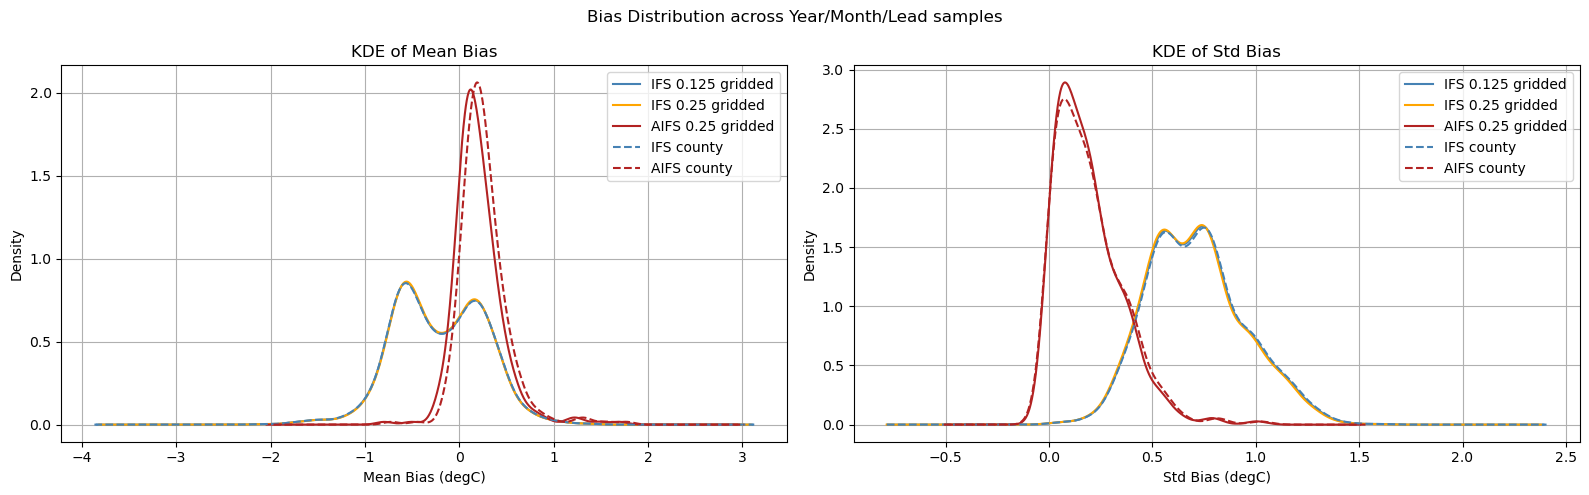

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for df_m, label, color, ls in [
    (ifs_grid_125, "IFS 0.125 gridded", "steelblue",  "-"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "orange",     "-"),
    (aifs_grid_25, "AIFS 0.25 gridded", "firebrick",  "-"),
    (ifs_county,   "IFS county",         "steelblue", "--"),
    (aifs_county,  "AIFS county",        "firebrick", "--"),
]:
    grouped = df_m.groupby(["year", "month", "lead"])["bias"]
    grouped.mean().dropna().plot.kde(ax=axes[0], label=label, color=color, ls=ls)
    grouped.std().dropna().plot.kde(ax=axes[1], label=label, color=color, ls=ls)

axes[0].set_xlabel("Mean Bias (degC)")
axes[0].set_ylabel("Density")
axes[0].set_title("KDE of Mean Bias")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Std Bias (degC)")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE of Std Bias")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Bias Distribution across Year/Month/Lead samples")
plt.tight_layout()
plt.show()

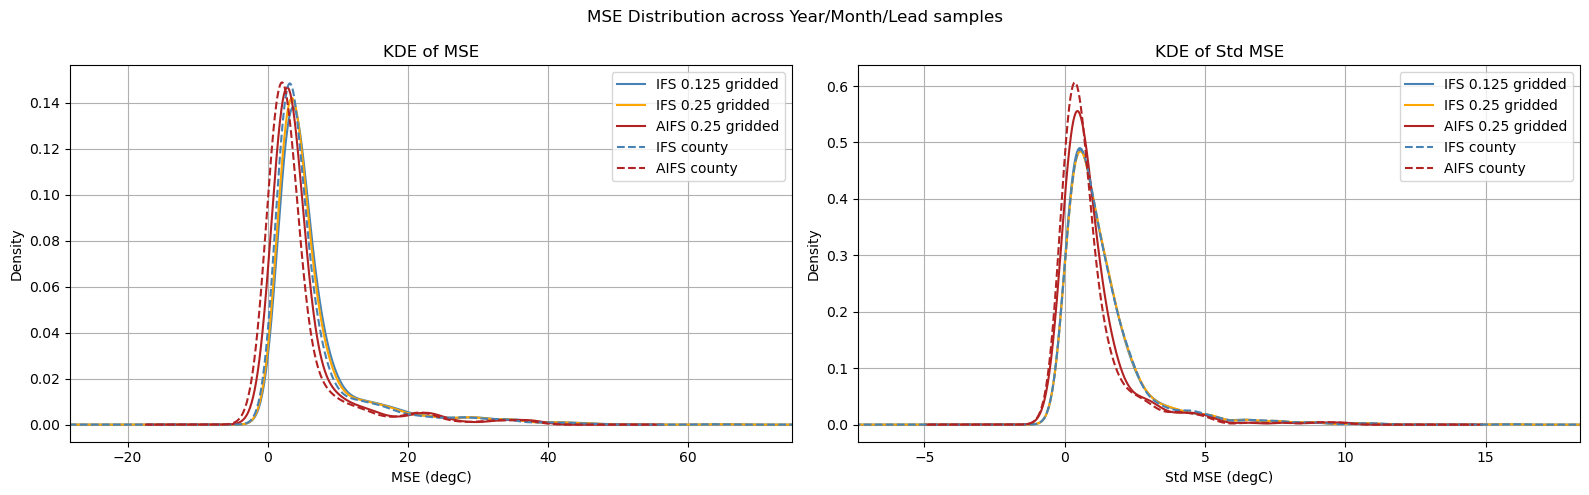

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for df_m, label, color, ls in [
    (ifs_grid_125, "IFS 0.125 gridded", "steelblue",  "-"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "orange",     "-"),
    (aifs_grid_25, "AIFS 0.25 gridded", "firebrick",  "-"),
    (ifs_county,   "IFS county",         "steelblue", "--"),
    (aifs_county,  "AIFS county",        "firebrick", "--"),
]:
    grouped = df_m.groupby(["year", "month", "lead"])["mse"]
    grouped.mean().dropna().plot.kde(ax=axes[0], label=label, color=color, ls=ls)
    grouped.std().dropna().plot.kde(ax=axes[1], label=label, color=color, ls=ls)

for ax in axes:
    data = []
    for line in ax.get_lines():
        xdata = line.get_xdata()
        data.append(xdata)
    all_data = np.concatenate(data)
    ax.set_xlim(np.nanpercentile(all_data, 1), np.nanpercentile(all_data, 90))
    
axes[0].set_xlabel("MSE (degC)")
axes[0].set_ylabel("Density")
axes[0].set_title("KDE of MSE")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Std MSE (degC)")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE of Std MSE")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("MSE Distribution across Year/Month/Lead samples")
plt.tight_layout()
plt.show()

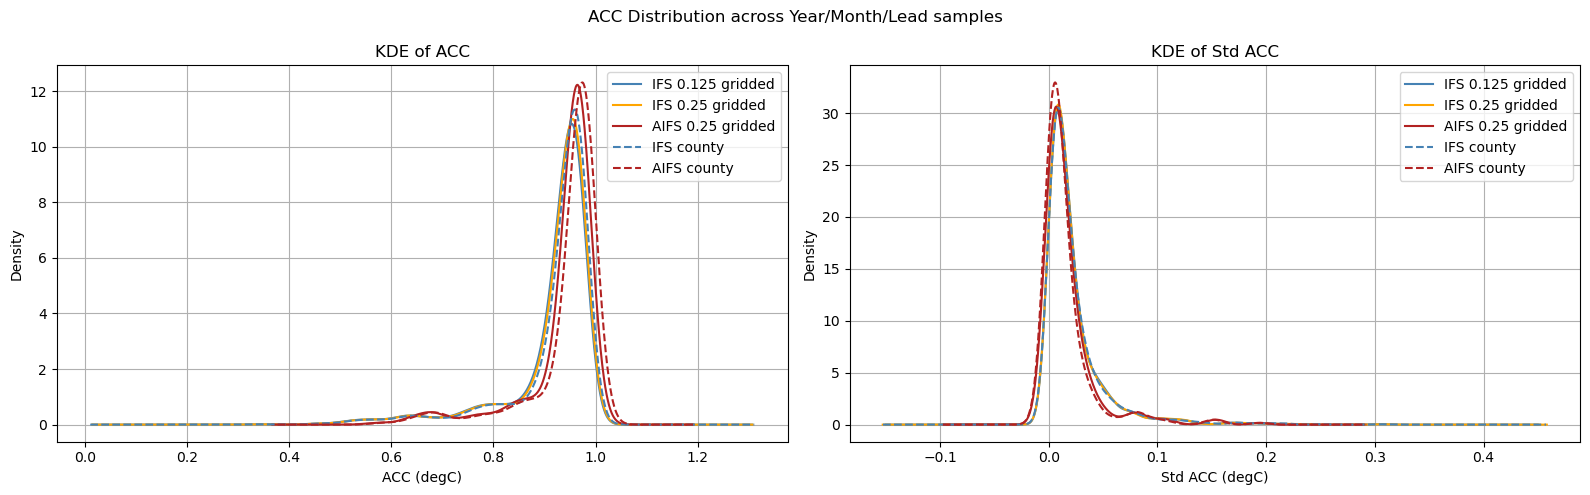

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for df_m, label, color, ls in [
    (ifs_grid_125, "IFS 0.125 gridded", "steelblue",  "-"),
    (ifs_grid_25,  "IFS 0.25 gridded",  "orange",     "-"),
    (aifs_grid_25, "AIFS 0.25 gridded", "firebrick",  "-"),
    (ifs_county,   "IFS county",         "steelblue", "--"),
    (aifs_county,  "AIFS county",        "firebrick", "--"),
]:
    grouped = df_m.groupby(["year", "month", "lead"])["acc"]
    grouped.mean().dropna().plot.kde(ax=axes[0], label=label, color=color, ls=ls)
    grouped.std().dropna().plot.kde(ax=axes[1], label=label, color=color, ls=ls)

axes[0].set_xlabel("ACC (degC)")
axes[0].set_ylabel("Density")
axes[0].set_title("KDE of ACC")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Std ACC (degC)")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE of Std ACC")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ACC Distribution across Year/Month/Lead samples")
plt.tight_layout()
plt.show()

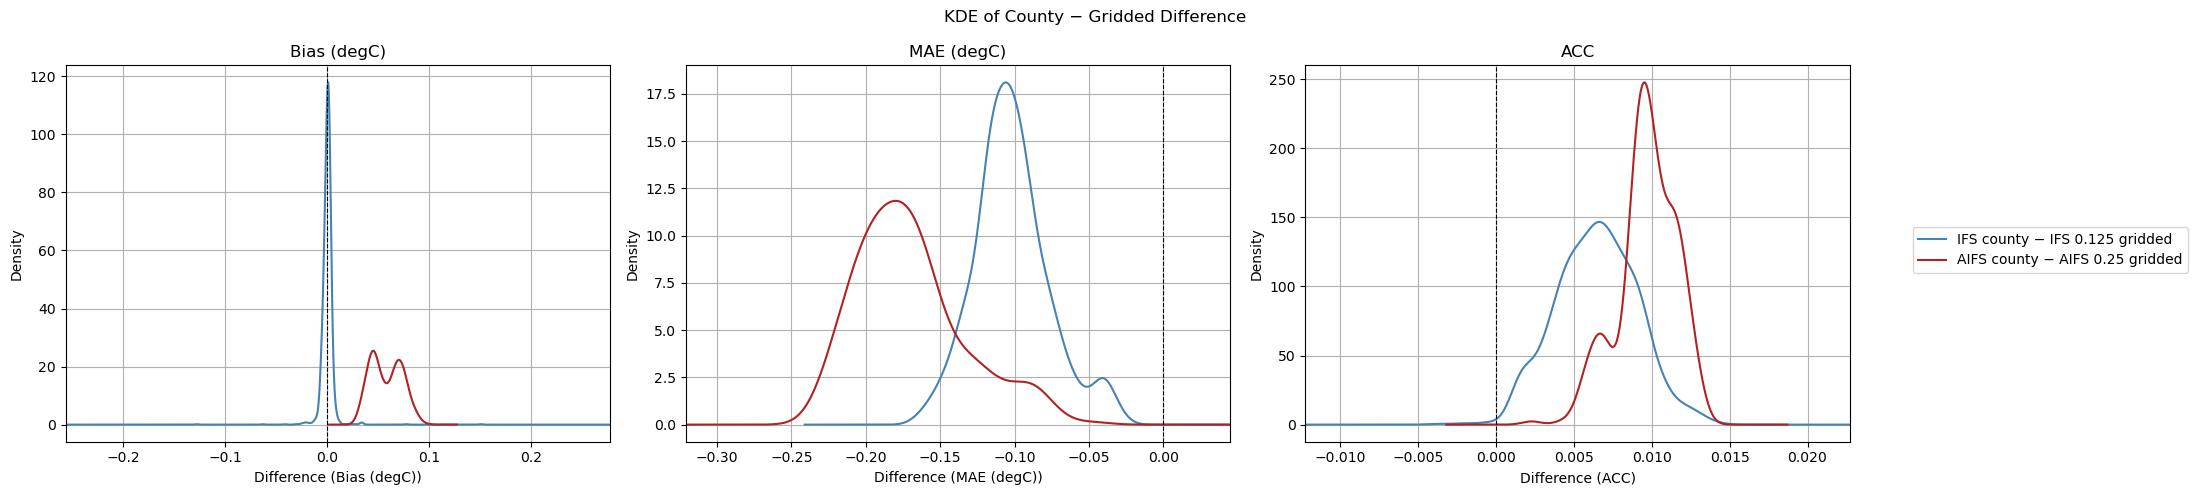

In [26]:
keys = ["year", "month", "lead"]

ifs_diff = (ifs_county.groupby(keys)[metrics].mean() - ifs_grid_125.groupby(keys)[metrics].mean()).dropna()
aifs_diff = (aifs_county.groupby(keys)[metrics].mean() - aifs_grid_25.groupby(keys)[metrics].mean()).dropna()

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
handles, labels = [], []
for ax, metric, title in zip(axes, metrics, titles):
    for i, (diff, label, color) in enumerate([
        (ifs_diff,  "IFS county − IFS 0.125 gridded", "steelblue"),
        (aifs_diff, "AIFS county − AIFS 0.25 gridded", "firebrick"),
    ]):
        line, = ax.plot([], [], color=color, label=label)
        diff[metric].plot.kde(ax=ax, label=label, color=color)
        if ax is axes[0]:
            handles.append(line)
            labels.append(label)

    all_data = np.concatenate([line.get_xdata() for line in ax.get_lines()])
    ax.set_xlim(np.nanpercentile(all_data, 1), np.nanpercentile(all_data, 99))
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel(f"Difference ({title})")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.grid(True)

fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), frameon=True)
plt.suptitle("KDE of County − Gridded Difference")
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [7]:
def plot_comparison(init, lead, year, month, geo_path, mask_125=None, mask_25=None, save=False):
    rows = []

    # IFS 0.125 gridded
    ds_fc = read_fc_files("ifs", init, lead, year, month)
    ds_an = read_an_files(init, lead, year, month)
    if ds_fc is not None and ds_an is not None:
        mask = mask_125
        if mask is not None:
            ds_fc = apply_mask(ds_fc, mask)
            ds_an = apply_mask(ds_an, mask)
        diff = ds_fc.t2m - ds_an.t2m
        rows.append({
            "label": "IFS 0.125 gridded",
            "bias": diff.mean(dim="time"),
            "mae": abs(diff).mean(dim="time"),
            "kind": "gridded",
        })

    # IFS 0.25 gridded
    ds_fc = read_fc_files("ifs", init, lead, year, month)
    ds_an = read_an_files(init, lead, year, month)
    if ds_fc is not None and ds_an is not None:
        ds_fc = coarsen(ds_fc)
        ds_an = coarsen(ds_an)
        mask = mask_25
        if mask is not None:
            ds_fc = apply_mask(ds_fc, mask)
            ds_an = apply_mask(ds_an, mask)
        diff = ds_fc.t2m - ds_an.t2m
        rows.append({
            "label": "IFS 0.25 gridded",
            "bias": diff.mean(dim="time"),
            "mae": abs(diff).mean(dim="time"),
            "kind": "gridded",
        })

    # IFS county
    df_bias = duckdb.query(f"""
        SELECT geo_id,
            SUM(bias * aland) / SUM(aland) as bias,
            SUM(ABS(bias) * aland) / SUM(aland) as mae
        FROM read_parquet('{IFS_COUNTY_PATH}')
        WHERE STRFTIME(init_time, '%H%M') = '{fix_init(init)}'
            AND CAST(lead_time AS INT) = {lead}
            AND YEAR(init_time) = {year}
            AND MONTH(init_time) = {month}
        GROUP BY geo_id
    """).df()
    gdf = gpd.read_file(geo_path).rename(columns={"GEOID": "geo_id"})
    gdf["geometry"] = gdf.geometry.simplify(1000)
    gdf = gdf.merge(df_bias, on="geo_id", how="inner").to_crs("EPSG:4326")
    if not gdf.empty:
        rows.append({"label": "IFS county", "gdf": gdf, "kind": "county"})

    # AIFS 0.25 gridded
    ds_fc = read_fc_files("aifs", init, lead, year, month)
    ds_an = read_an_files(init, lead, year, month)
    if ds_fc is not None and ds_an is not None:
        ds_an = coarsen(ds_an)
        mask = mask_25
        if mask is not None:
            ds_fc = apply_mask(ds_fc, mask)
            ds_an = apply_mask(ds_an, mask)
        diff = ds_fc.t2m - ds_an.t2m
        rows.append({
            "label": "AIFS 0.25 gridded",
            "bias": diff.mean(dim="time"),
            "mae": abs(diff).mean(dim="time"),
            "kind": "gridded",
        })

    # AIFS county
    if fc_data_exists("aifs", init, lead, year, month):
        df_bias = duckdb.query(f"""
            SELECT geo_id,
                SUM(bias * aland) / SUM(aland) as bias,
                SUM(ABS(bias) * aland) / SUM(aland) as mae
            FROM read_parquet('{AIFS_COUNTY_PATH}')
            WHERE STRFTIME(init_time, '%H%M') = '{fix_init(init)}'
                AND CAST(lead_time AS INT) = {lead}
                AND YEAR(init_time) = {year}
                AND MONTH(init_time) = {month}
            GROUP BY geo_id
        """).df()
        gdf = gpd.read_file(geo_path).rename(columns={"GEOID": "geo_id"})
        gdf["geometry"] = gdf.geometry.simplify(1000)
        gdf = gdf.merge(df_bias, on="geo_id", how="inner").to_crs("EPSG:4326")
        if not gdf.empty:
            rows.append({"label": "AIFS county", "gdf": gdf, "kind": "county"})

    n_rows = len(rows)

    # Compute shared color limits
    all_bias_vals = []
    all_mae_vals = []
    for row in rows:
        if row["kind"] == "gridded":
            all_bias_vals.append(row["bias"].values[~np.isnan(row["bias"].values)])
            all_mae_vals.append(row["mae"].values[~np.isnan(row["mae"].values)])
        else:
            all_bias_vals.append(row["gdf"]["bias"].abs().values)
            all_mae_vals.append(row["gdf"]["mae"].values)
    bias_lim = np.percentile(np.abs(np.concatenate([np.atleast_1d(v) for v in all_bias_vals])), 90)
    mae_max  = np.percentile(np.concatenate([np.atleast_1d(v) for v in all_mae_vals]), 90)
    bias_norm = plt.Normalize(vmin=-bias_lim, vmax=bias_lim)
    mae_norm  = plt.Normalize(vmin=0, vmax=mae_max)
    bias_cmap = plt.cm.RdBu_r
    mae_cmap  = plt.cm.Reds

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(2, n_rows, figsize=(5 * n_rows, 8),
                             subplot_kw={"projection": proj})
    axes = np.atleast_2d(axes)

    # Compute CONUS bounds from first gridded row
    ref = next(r for r in rows if r["kind"] == "gridded")["bias"]
    lon_min, lon_max = float(ref.longitude.min()), float(ref.longitude.max())
    lat_min, lat_max = float(ref.latitude.min()), float(ref.latitude.max())

    for i, row in enumerate(rows):
        ax_bias = axes[0, i]
        ax_mae  = axes[1, i]
        for ax, col, norm, cmap in [
            (ax_bias, "bias", bias_norm, bias_cmap),
            (ax_mae,  "mae",  mae_norm,  mae_cmap),
        ]:
            if row["kind"] == "gridded":
                lons = row[col].longitude.values
                lats = row[col].latitude.values
                data = row[col].values
                ax.pcolormesh(
                    lons, lats, data,
                    cmap=cmap, norm=norm,
                    transform=ccrs.PlateCarree(),
                    linewidth=0,
                    antialiased=False,
                    rasterized=True,
                )
            else:
                row["gdf"].plot(column=col, ax=ax, cmap=cmap, norm=norm,
                                legend=False, transform=ccrs.PlateCarree(),
                                edgecolor="none", linewidth=0, rasterized=True)
            ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
            ax.axis("off")

        ax_bias.set_title(f"{row['label']} — Bias")
        ax_mae.set_title(f"{row['label']} — MAE")

    sm_bias = plt.cm.ScalarMappable(cmap=bias_cmap, norm=bias_norm)
    sm_bias.set_array([])
    sm_mae = plt.cm.ScalarMappable(cmap=mae_cmap, norm=mae_norm)
    sm_mae.set_array([])
    for i in range(n_rows):
        for j in range(2):
            axes[j, i].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
            axes[j, i].set_aspect(1.5)
    fig.colorbar(sm_bias, ax=axes[0].tolist(), fraction=0.02, pad=0.04, label="Bias (degC)")
    fig.colorbar(sm_mae,  ax=axes[1].tolist(), fraction=0.02, pad=0.04, label="MAE (degC)")
    plt.suptitle(f"Bias & MAE — {year}/{month:02} init={init} lead={lead}")
    plt.subplots_adjust(left=0.02, right=0.88, top=0.93, bottom=0.02, wspace=0.05, hspace=0.1)
    if save:
        outfile = f"comparison_bias_mae_{init}_lead{lead}h_{year}_{month:02}.pdf"
        plt.savefig(outfile, dpi=300)
        print(outfile + " saved.")
    plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

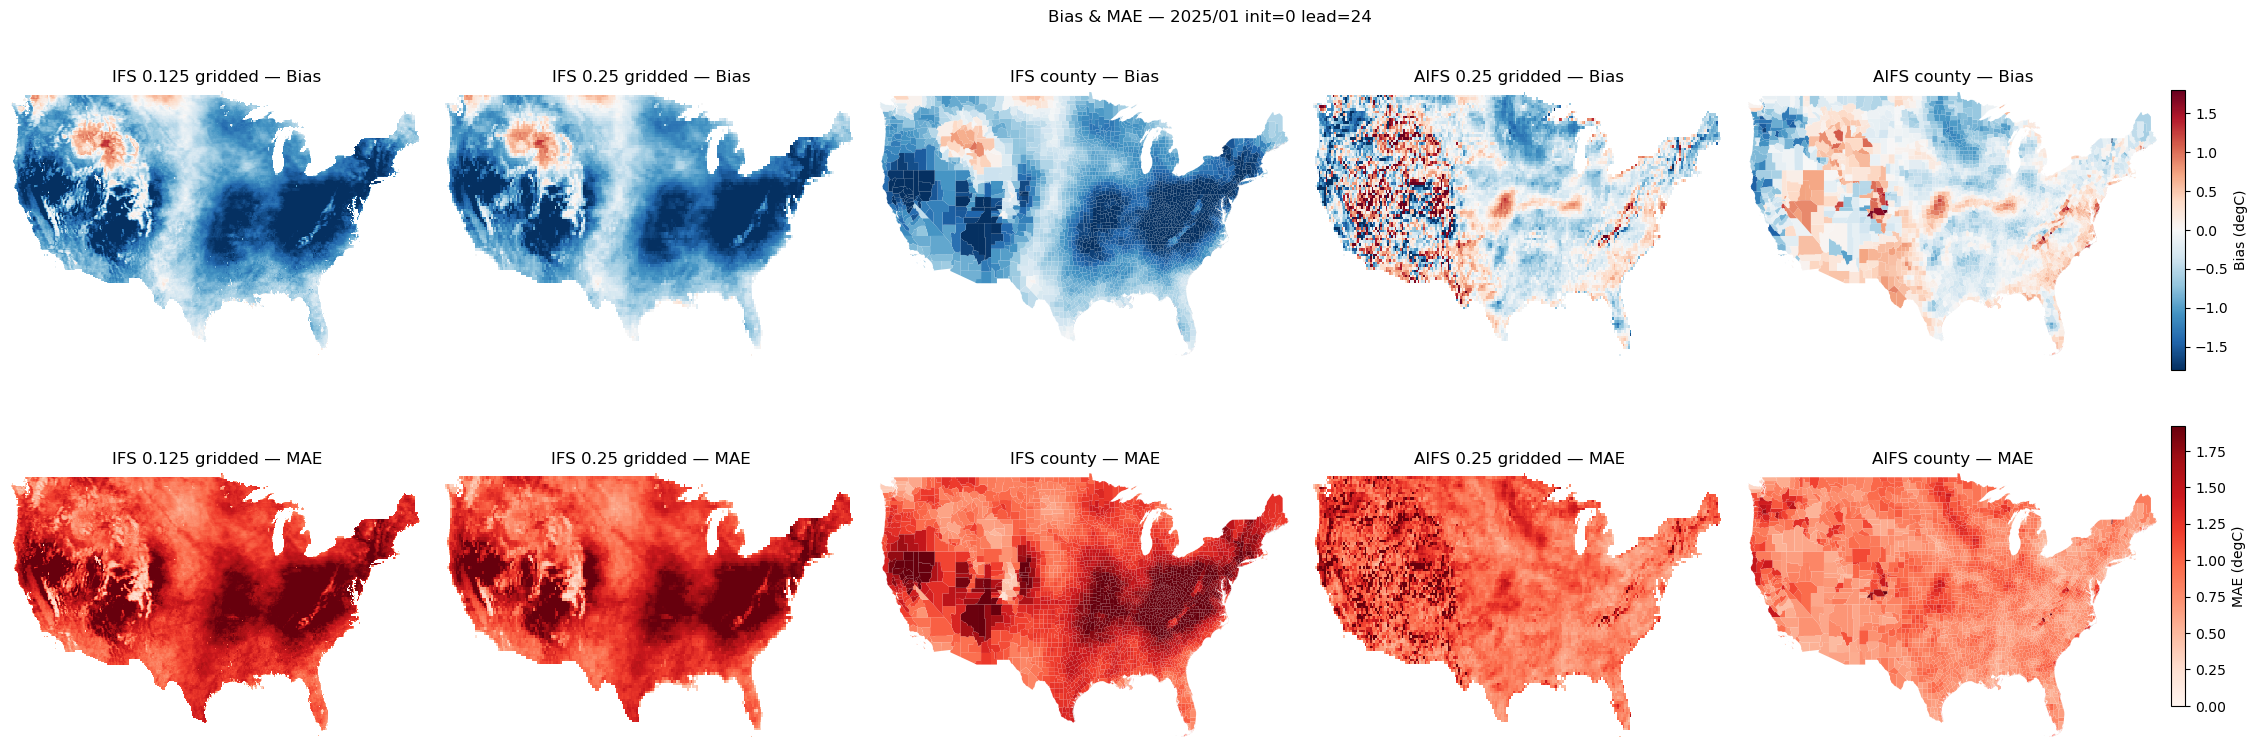

In [10]:
plot_comparison(0, 24, 2025, 1, SHAPEFILE, mask_125=mask, mask_25=mask_coarse)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

comparison_bias_mae_0_lead24h_2026_01.pdf saved.


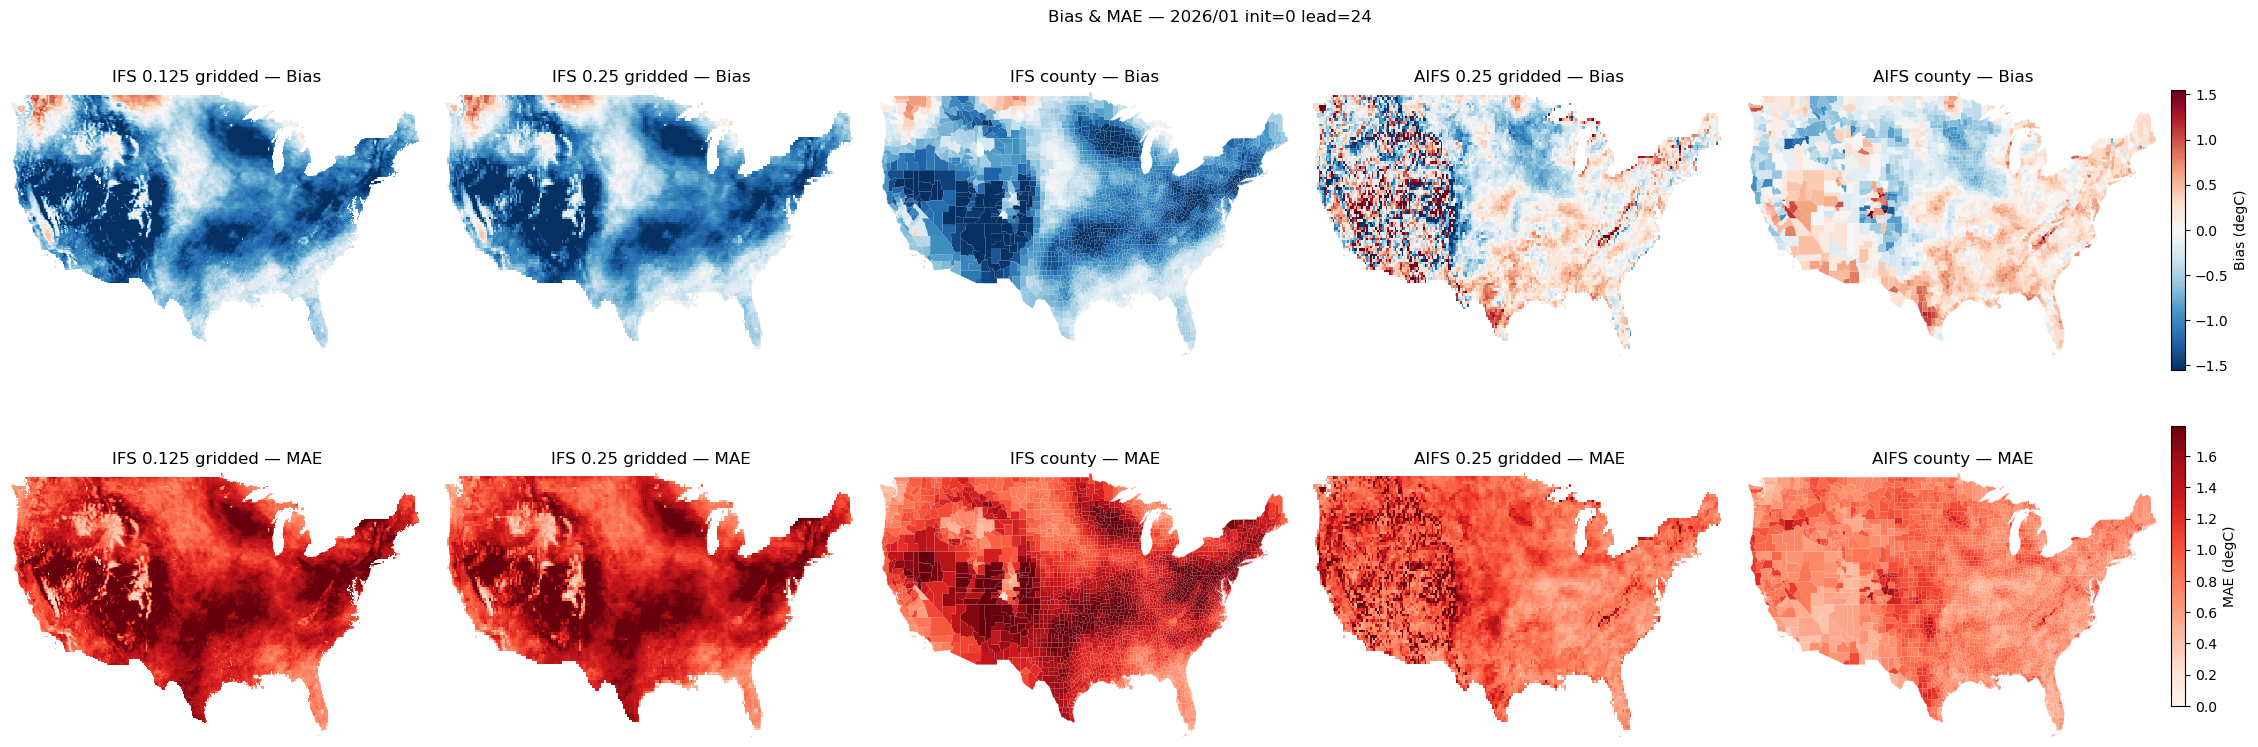

In [11]:
plot_comparison(0, 24, 2026, 1, SHAPEFILE, mask_125=mask, mask_25=mask_coarse, save=True)

comparison_bias_mae_12_lead24h_2026_01.pdf saved.


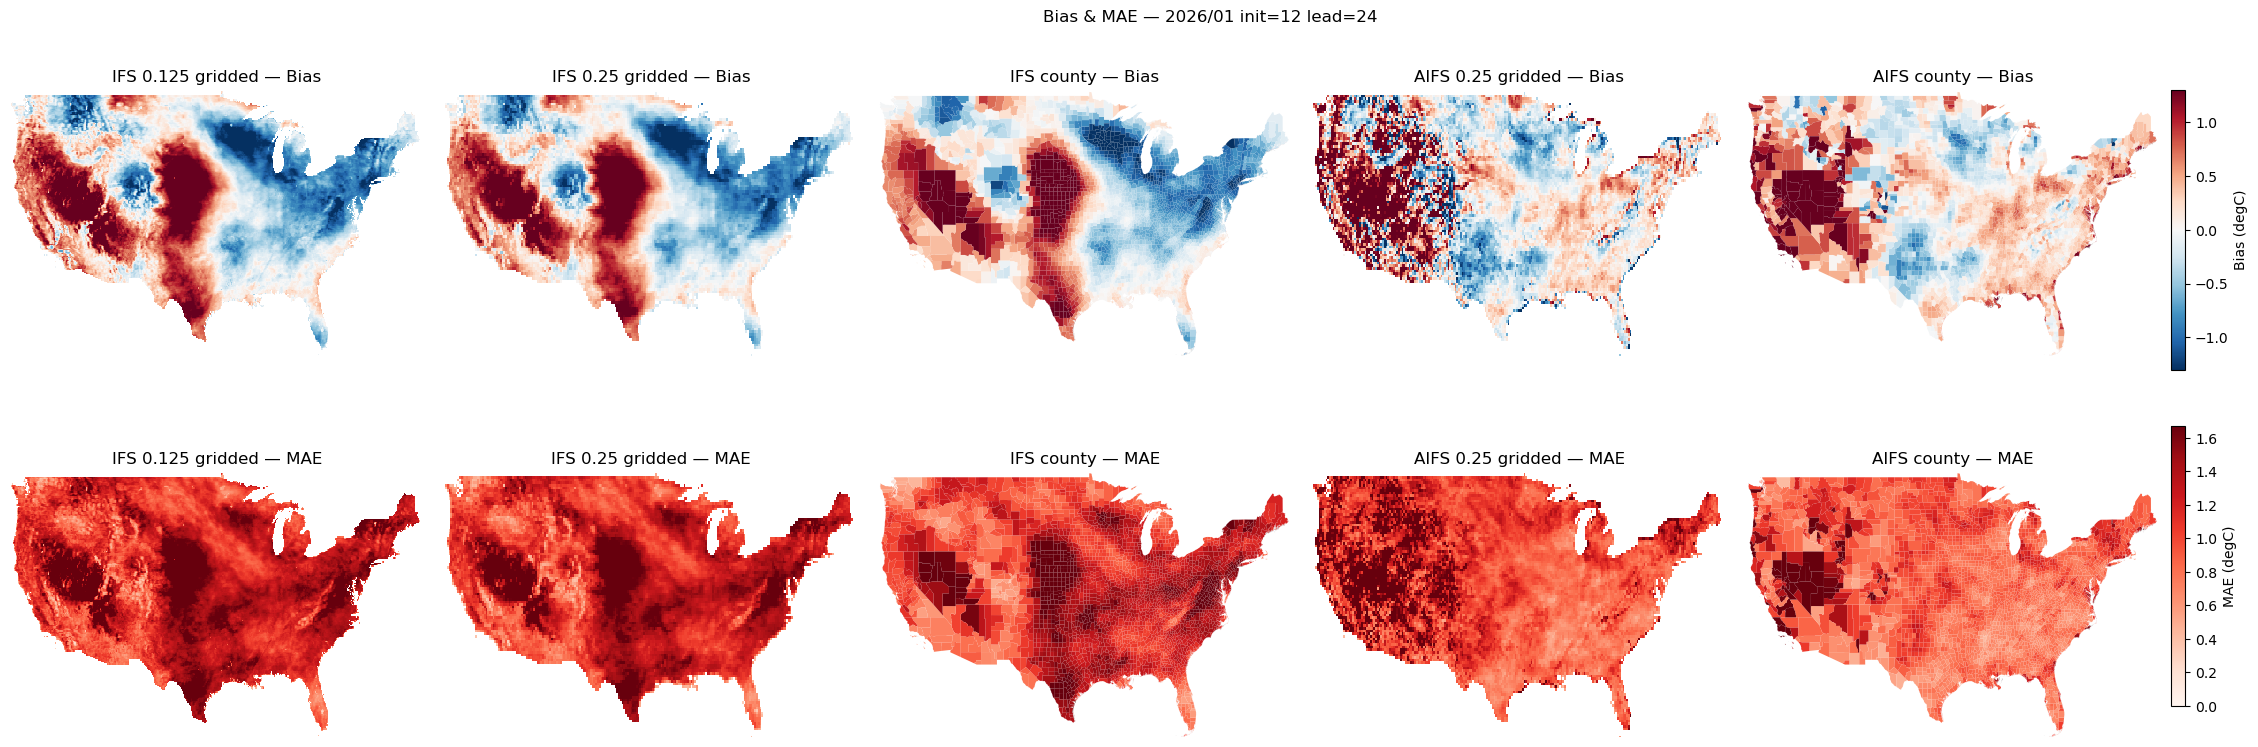

In [12]:
plot_comparison(12, 24, 2026, 1, SHAPEFILE, mask_125=mask, mask_25=mask_coarse, save=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

comparison_bias_mae_0_lead168h_2026_01.pdf saved.


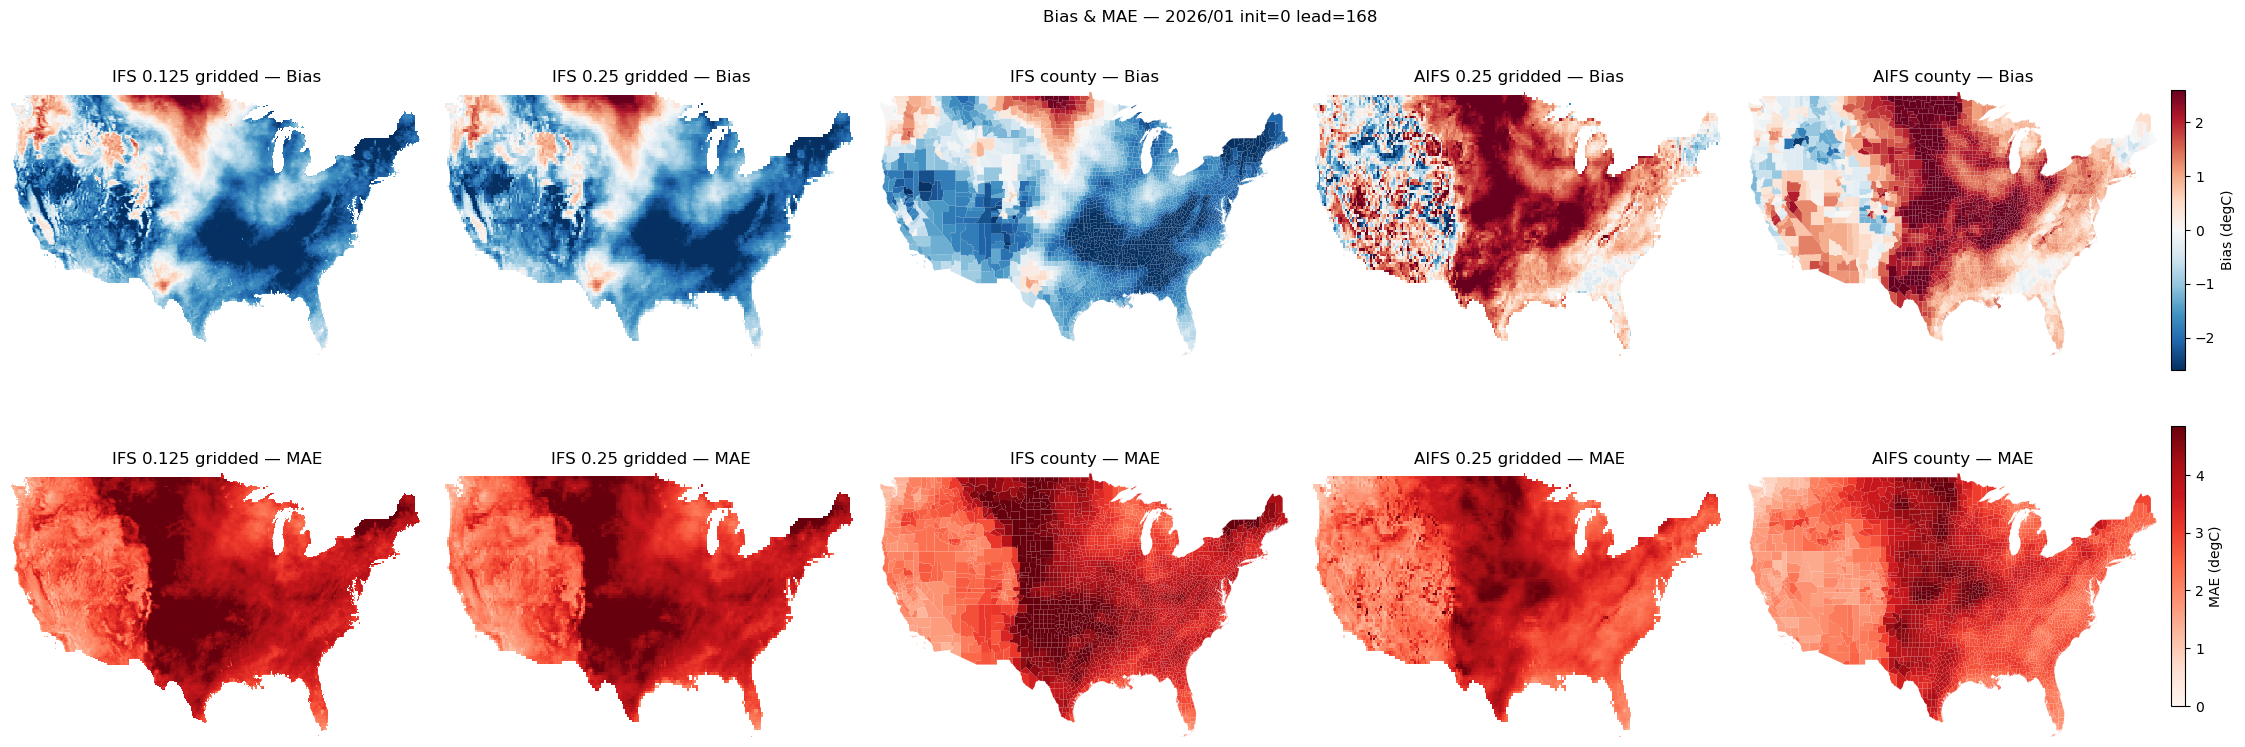

In [13]:
plot_comparison(0, 168, 2026, 1, SHAPEFILE, mask_125=mask, mask_25=mask_coarse, save=True)

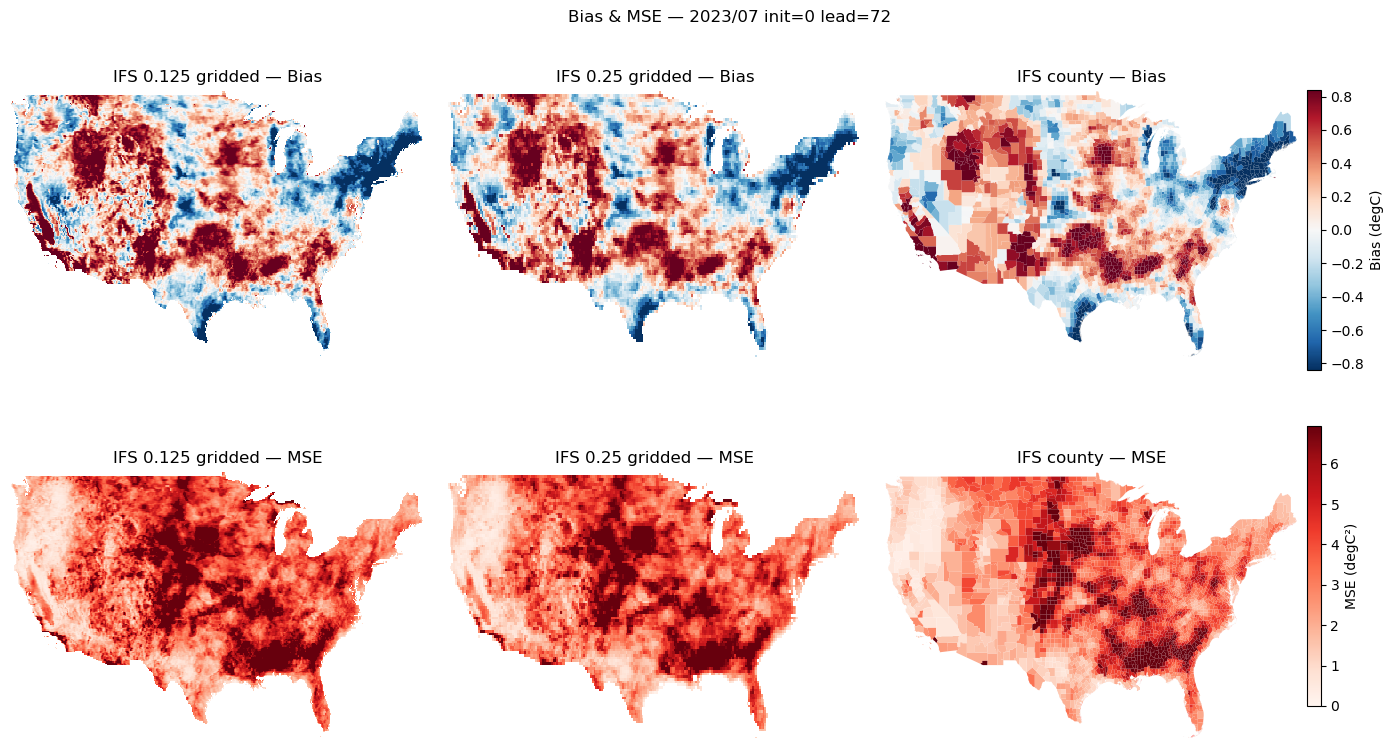

In [33]:
plot_comparison(0, 72, 2023, 7, SHAPEFILE, mask_125=mask, mask_25=mask_coarse, save=False)

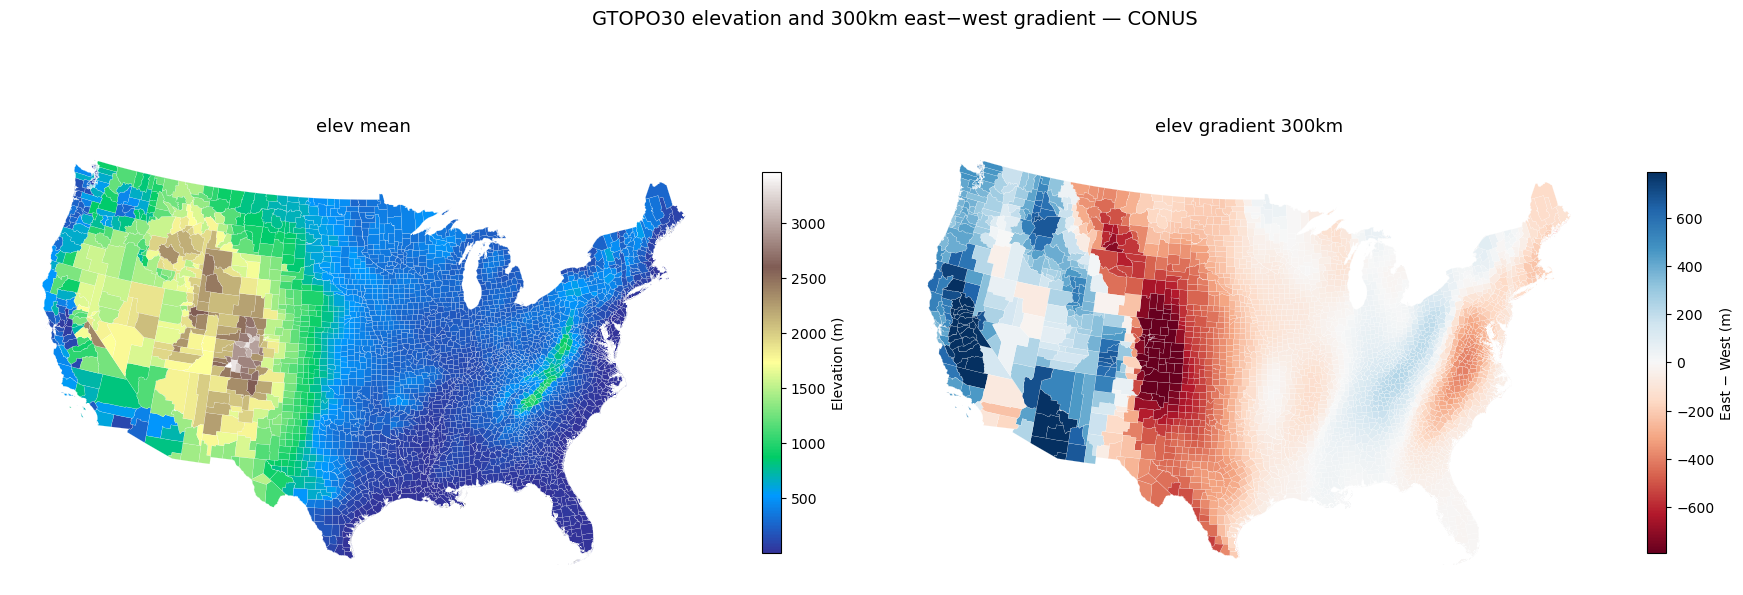

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

specs = {
    "elev_mean":           ("terrain", "Elevation (m)", None, None),
    "elev_gradient_300km": ("RdBu",    "East − West (m)",
                            -df["elev_gradient_300km"].abs().quantile(0.98),
                             df["elev_gradient_300km"].abs().quantile(0.98)),
}

for ax, (col, (cmap, label, vmin, vmax)) in zip(axes, specs.items()):
    gdf_plot = gdf.merge(df[["geo_id", col]], left_on="GEOID", right_on="geo_id", how="left")
    gdf_plot.plot(column=col, ax=ax, cmap=cmap, legend=True,
                  vmin=vmin, vmax=vmax,
                  linewidth=0.1, edgecolor="white",
                  legend_kwds={"shrink": 0.6, "label": label})
    ax.set_axis_off()
    ax.set_title(col.replace("_", " "), fontsize=13)

plt.suptitle("GTOPO30 elevation and 300km east−west gradient — CONUS", fontsize=14)
plt.tight_layout()
plt.savefig("elevation_gradient_300km_map.pdf", dpi=300)
plt.show()

In [38]:
duckdb.query("""
    SELECT 
        CASE 
            WHEN k.category_1 IN (1,2,3) THEN 'A'
            WHEN k.category_1 IN (4,5,6,7,8,9) THEN 'B'
            WHEN k.category_1 IN (14,15,16,17,18,19,20) THEN 'C'
            WHEN k.category_1 IN (21,22,23,24,25,26,27,28,29) THEN 'D'
            ELSE 'Other'
        END AS koppen_class,
        AVG(b.bias)                AS mean_bias,
        SQRT(AVG(b.bias * b.bias)) AS rmse,
        AVG(b.abs_error)           AS mae,
        COUNT(*)                   AS n
    FROM read_parquet('/glade/derecho/scratch/dcalhoun/aggregated/ifs_fc_bias_anom_2t_county.parquet') b
    JOIN read_parquet('/glade/derecho/scratch/dcalhoun/aggregated/koppen_geiger_county.parquet') k
      ON b.geo_id = k.geo_id
    WHERE b.lead_time = 24
    GROUP BY koppen_class
    ORDER BY rmse
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,koppen_class,mean_bias,rmse,mae,n
0,A,-0.777923,1.161432,0.956821,51968
1,D,-0.307472,1.481650,1.137057,8693504
2,B,-0.044495,1.486821,1.159545,3006720
3,C,-0.413924,1.498541,1.143462,11329024


In [39]:
import duckdb

LEADS = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
leads_sql = ", ".join(str(l) for l in LEADS)

for model, path, valid_start, valid_end in [
    ("IFS full",   "/glade/derecho/scratch/dcalhoun/aggregated/ifs_fc_bias_anom_2t_county.parquet",  "2016-01-01", "2025-12-31"),
    ("IFS common", "/glade/derecho/scratch/dcalhoun/aggregated/ifs_fc_bias_anom_2t_county.parquet",  "2024-03-11", "2026-03-10"),
    ("AIFS common","/glade/derecho/scratch/dcalhoun/aggregated/aifs_fc_bias_anom_2t_county.parquet", "2024-03-11", "2026-03-10"),
]:
    r = duckdb.query(f"""
        SELECT
            COUNT(*)                            AS n_rows,
            COUNT(DISTINCT geo_id)              AS n_counties,
            COUNT(DISTINCT lead_time)           AS n_leads,
            LIST(DISTINCT lead_time ORDER BY lead_time) AS leads,
            COUNT(DISTINCT HOUR(valid_time))    AS n_valid_hours,
            LIST(DISTINCT HOUR(valid_time))     AS valid_hours,
            MIN(valid_time)                     AS min_valid,
            MAX(valid_time)                     AS max_valid,
            COUNT(DISTINCT CAST(valid_time AS DATE)) AS n_valid_dates
        FROM read_parquet('{path}')
        WHERE valid_time >= '{valid_start}'
          AND valid_time <= '{valid_end}'
          AND lead_time IN ({leads_sql})
    """).df()
    print(f"\n=== {model} ===")
    print(r.T.to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== IFS full ===
                                                                  0
n_rows                                                    272525613
n_counties                                                     3109
n_leads                                                          12
leads          [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
n_valid_hours                                                     2
valid_hours                                                 [0, 12]
min_valid                                       2016-01-01 00:00:00
max_valid                                       2025-12-31 00:00:00
n_valid_dates                                                  3653


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== IFS common ===
                                                                  0
n_rows                                                     54432372
n_counties                                                     3109
n_leads                                                          12
leads          [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
n_valid_hours                                                     2
valid_hours                                                 [0, 12]
min_valid                                       2024-03-11 00:00:00
max_valid                                       2026-03-10 00:00:00
n_valid_dates                                                   730


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== AIFS common ===
                                                                  0
n_rows                                                     54432372
n_counties                                                     3109
n_leads                                                          12
leads          [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
n_valid_hours                                                     2
valid_hours                                                 [0, 12]
min_valid                                       2024-03-11 00:00:00
max_valid                                       2026-03-10 00:00:00
n_valid_dates                                                   730


In [ ]:
import duckdb
import pandas as pd

LEADS = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]
leads_sql = ", ".join(str(l) for l in LEADS)

IFS_PATH  = "/glade/derecho/scratch/dcalhoun/aggregated/ifs_fc_bias_anom_2t_county.parquet"
AIFS_PATH = "/glade/derecho/scratch/dcalhoun/aggregated/aifs_fc_bias_anom_2t_county.parquet"

PERIODS = {
    "ifs_full":   (IFS_PATH,  "2016-01-01", "2025-12-31"),
    "ifs_common": (IFS_PATH,  "2024-03-11", "2026-03-10"),
    "aifs_common":(AIFS_PATH, "2024-03-11", "2026-03-10"),
}

def build_exceedance_index(path, valid_start, valid_end, leads_sql, threshold=0.90):
    """
    For each valid_time x lead, compute the cross-sectional threshold of
    abs_error at the given quantile across all counties. Flag each county
    as exceeding that threshold, then collapse across leads by averaging
    to produce Y_bar_it in [0,1].
    
    Returns DataFrame: geo_id, valid_time, valid_hour, month, exceedance
    """
    return duckdb.query(f"""
        WITH base AS (
            SELECT
                geo_id,
                valid_time,
                lead_time,
                abs_error,
                HOUR(valid_time)  AS valid_hour,
                MONTH(valid_time) AS month
            FROM read_parquet('{path}')
            WHERE valid_time >= '{valid_start}'
              AND valid_time <= '{valid_end}'
              AND lead_time IN ({leads_sql})
        ),
        thresholds AS (
            SELECT
                valid_time,
                lead_time,
                QUANTILE_CONT(abs_error, {threshold}) AS threshold
            FROM base
            GROUP BY valid_time, lead_time
        ),
        flagged AS (
            SELECT
                b.geo_id,
                b.valid_time,
                b.valid_hour,
                b.month,
                b.lead_time,
                CASE WHEN b.abs_error > t.threshold THEN 1.0 ELSE 0.0 END AS exceeded
            FROM base b
            JOIN thresholds t
              ON b.valid_time = t.valid_time
             AND b.lead_time  = t.lead_time
        )
        SELECT
            geo_id,
            valid_time,
            valid_hour,
            month,
            AVG(exceeded) AS exceedance
        FROM flagged
        GROUP BY geo_id, valid_time, valid_hour, month
        ORDER BY geo_id, valid_time
    """).df()

exceedance = {}
for name, (path, valid_start, valid_end) in PERIODS.items():
    print(f"Building exceedance index: {name} ...")
    df = build_exceedance_index(path, valid_start, valid_end, leads_sql)
    exceedance[name] = df
    print(f"  {len(df):,} rows | shape {df.shape}")
    print(f"  exceedance mean={df['exceedance'].mean():.4f} "
          f"min={df['exceedance'].min():.4f} "
          f"max={df['exceedance'].max():.4f}")
    print(f"  valid_hour values: {sorted(df['valid_hour'].unique())}")
    print(f"  month values: {sorted(df['month'].unique())}")

Building exceedance index: ifs_full ...
